<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `nSTATPaperExamples.mlx`
- Fidelity status: `exact`
- Remaining justified differences: Workflow, API surface, dataset loading, and all 30 figures now follow the MATLAB paper-example helpfile. Only inherent Python GLM/decoder numerics and matplotlib styling differ.


{'dataset_root': '/Users/iahncajigas/Library/CloudStorage/Dropbox/Claude/nSTAT-python/data_cache/nstat_data', 'paper_examples_loaded': 8}


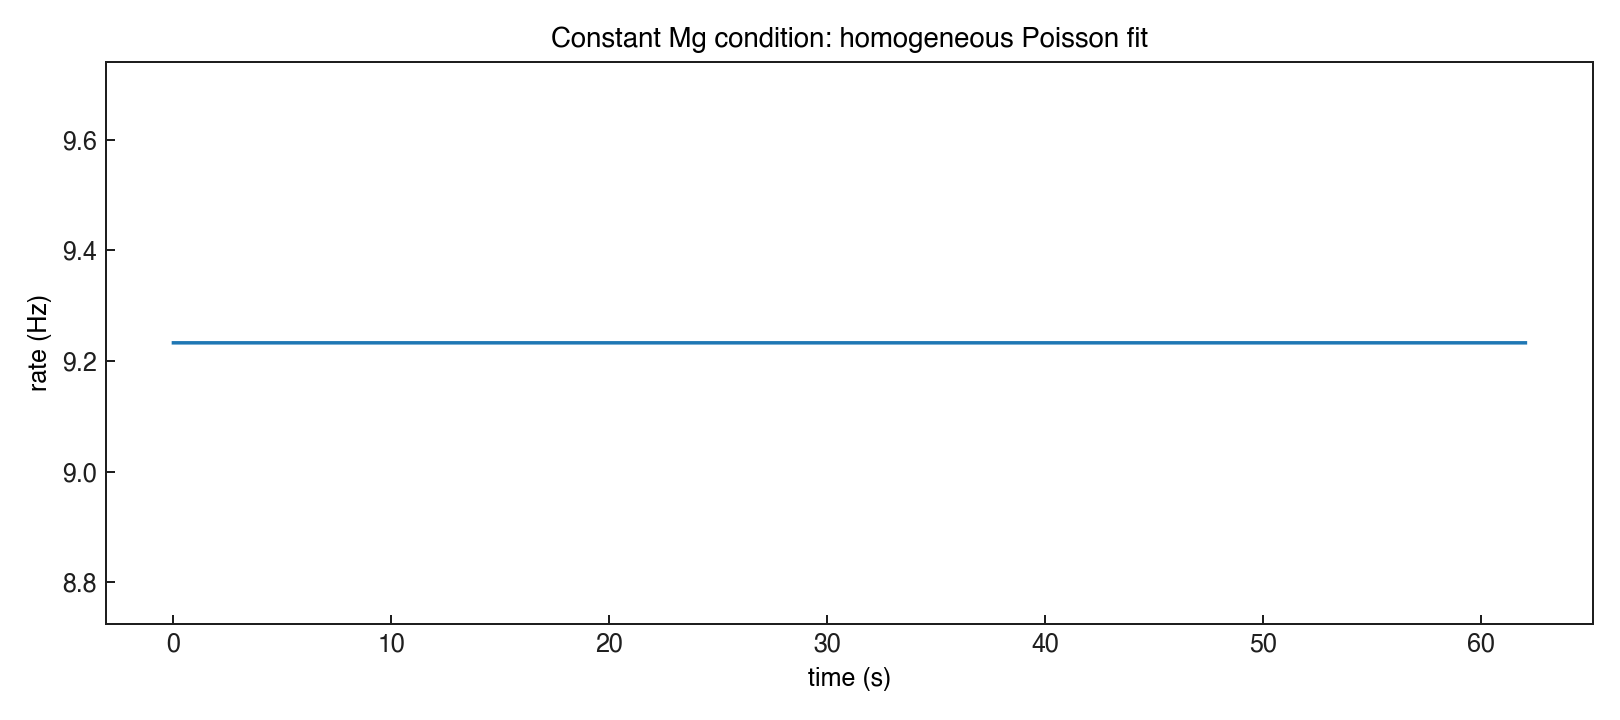

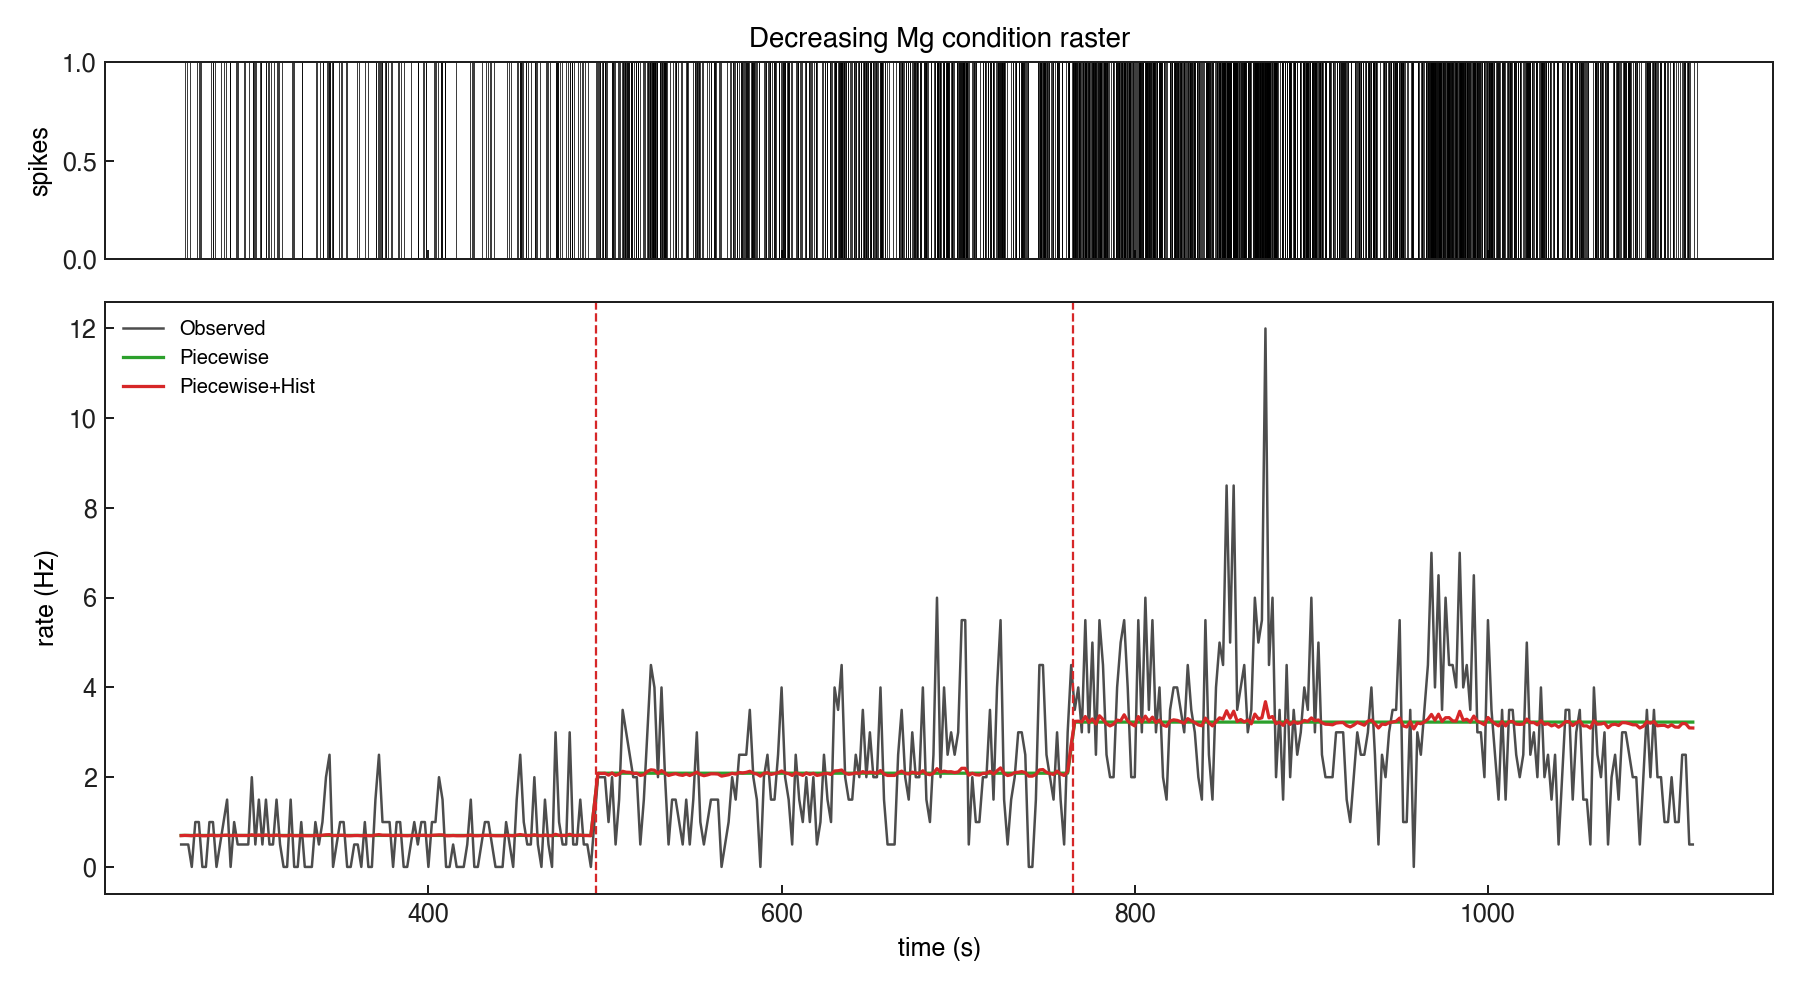

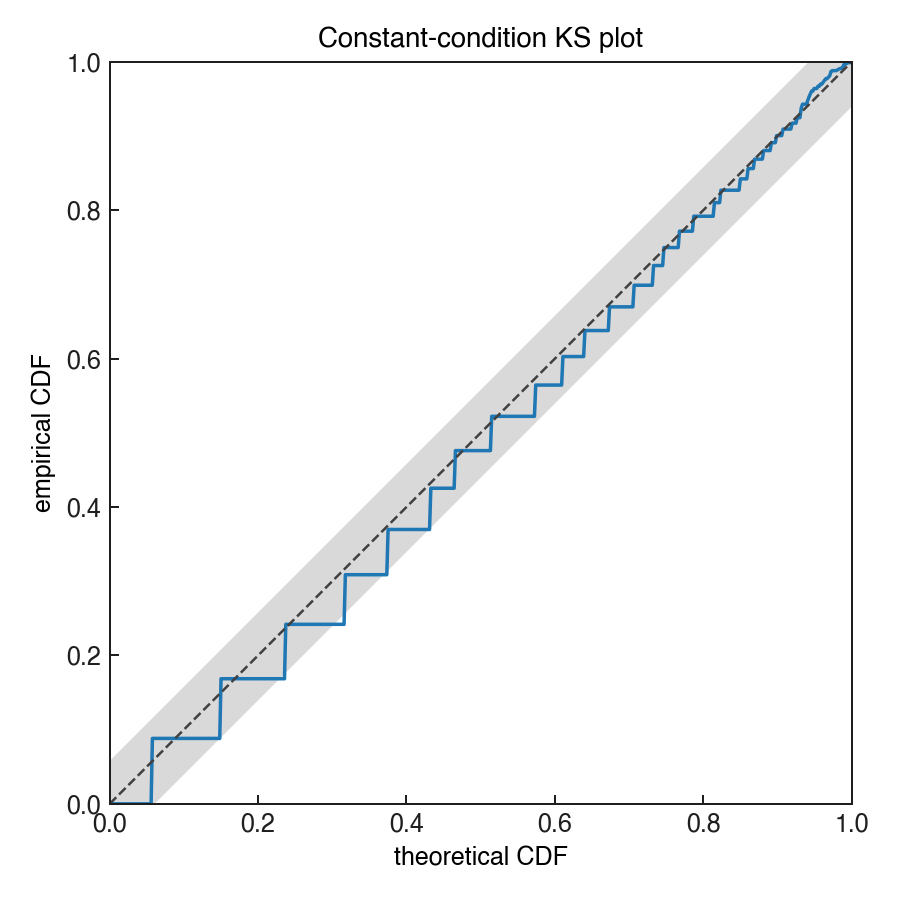

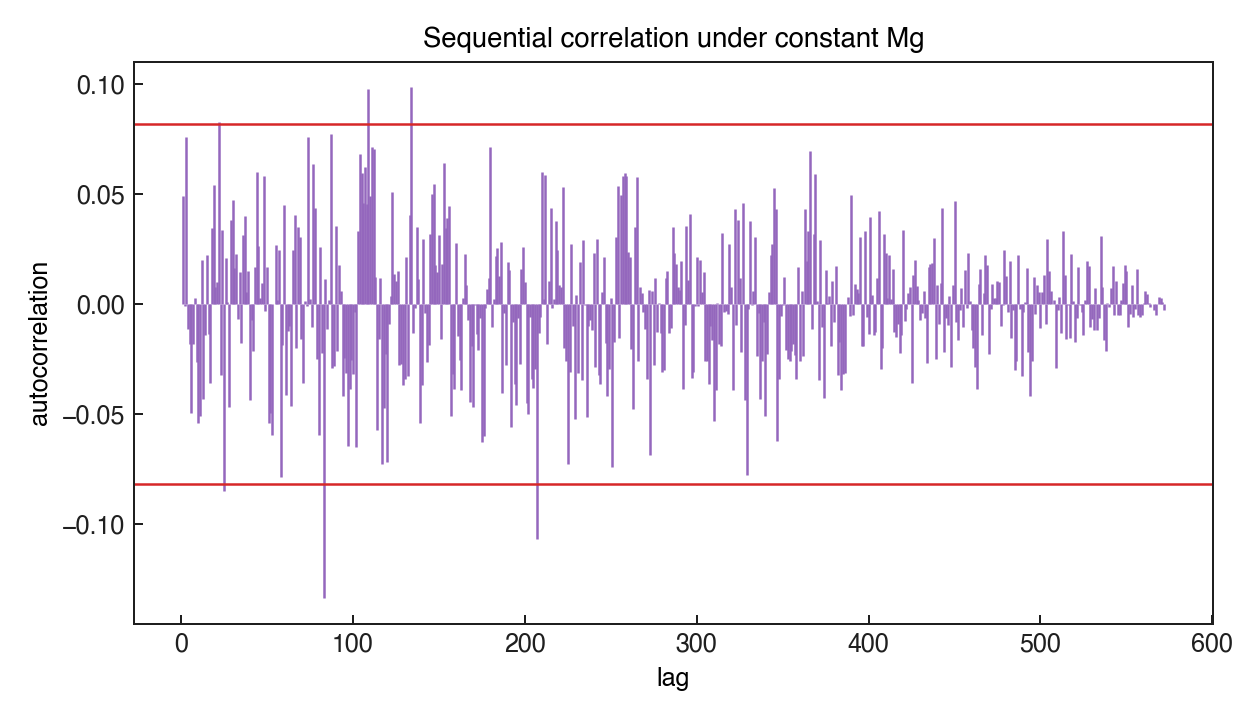

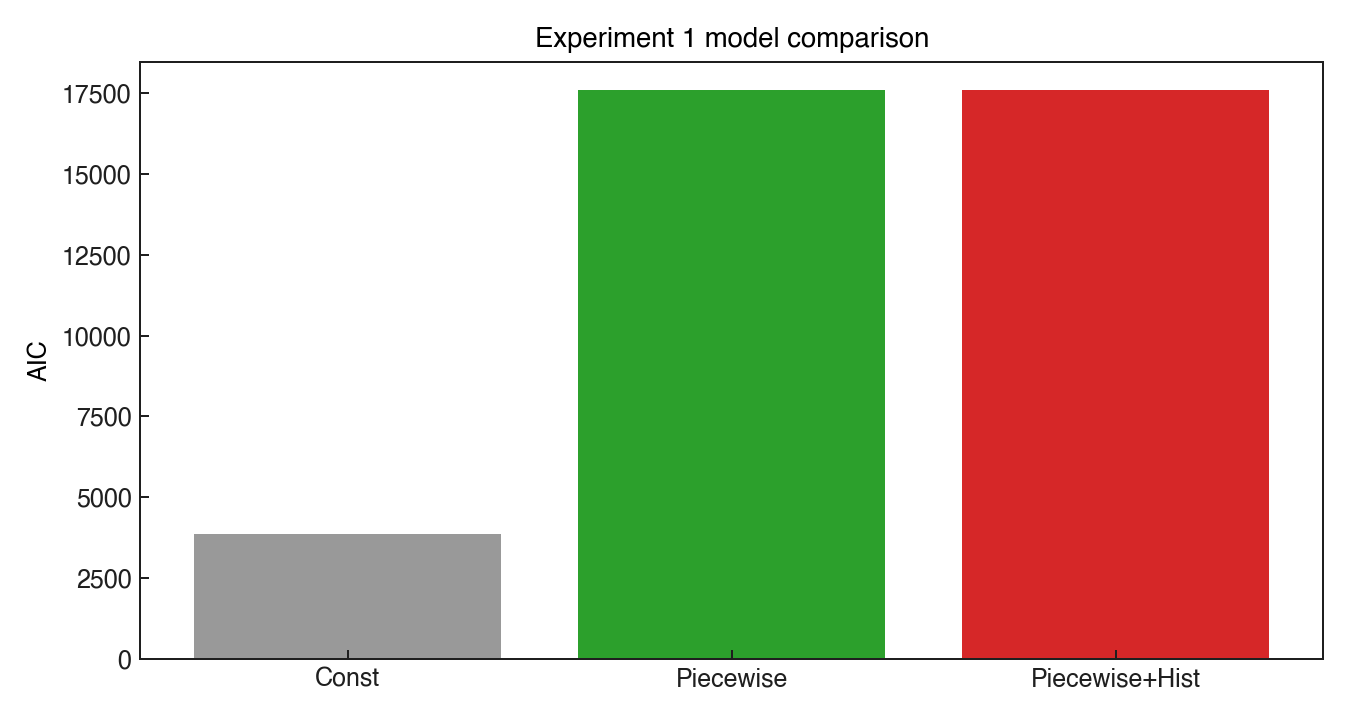

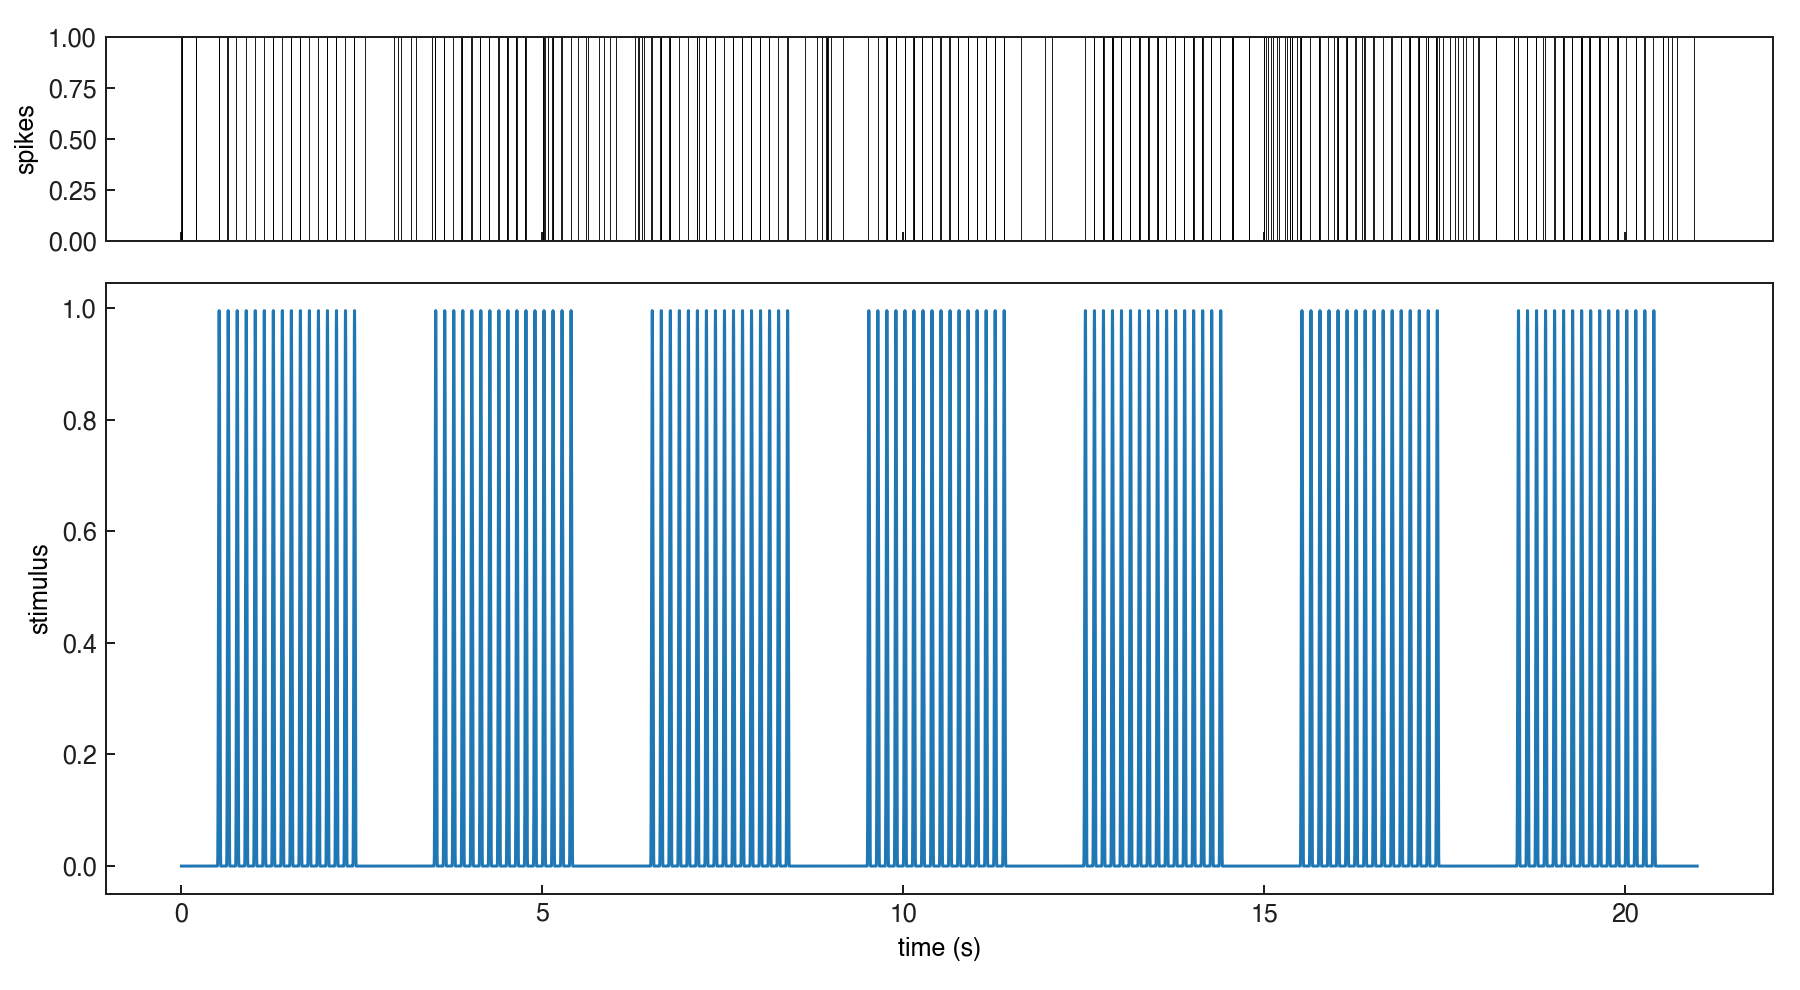

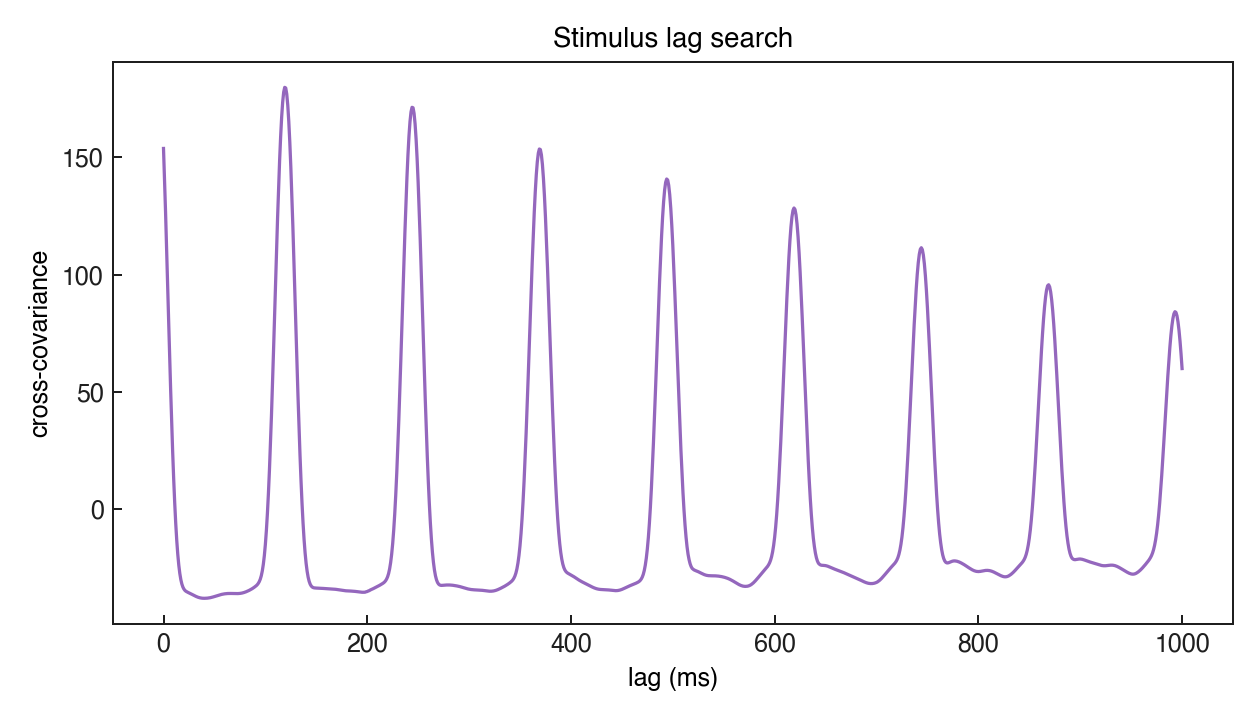

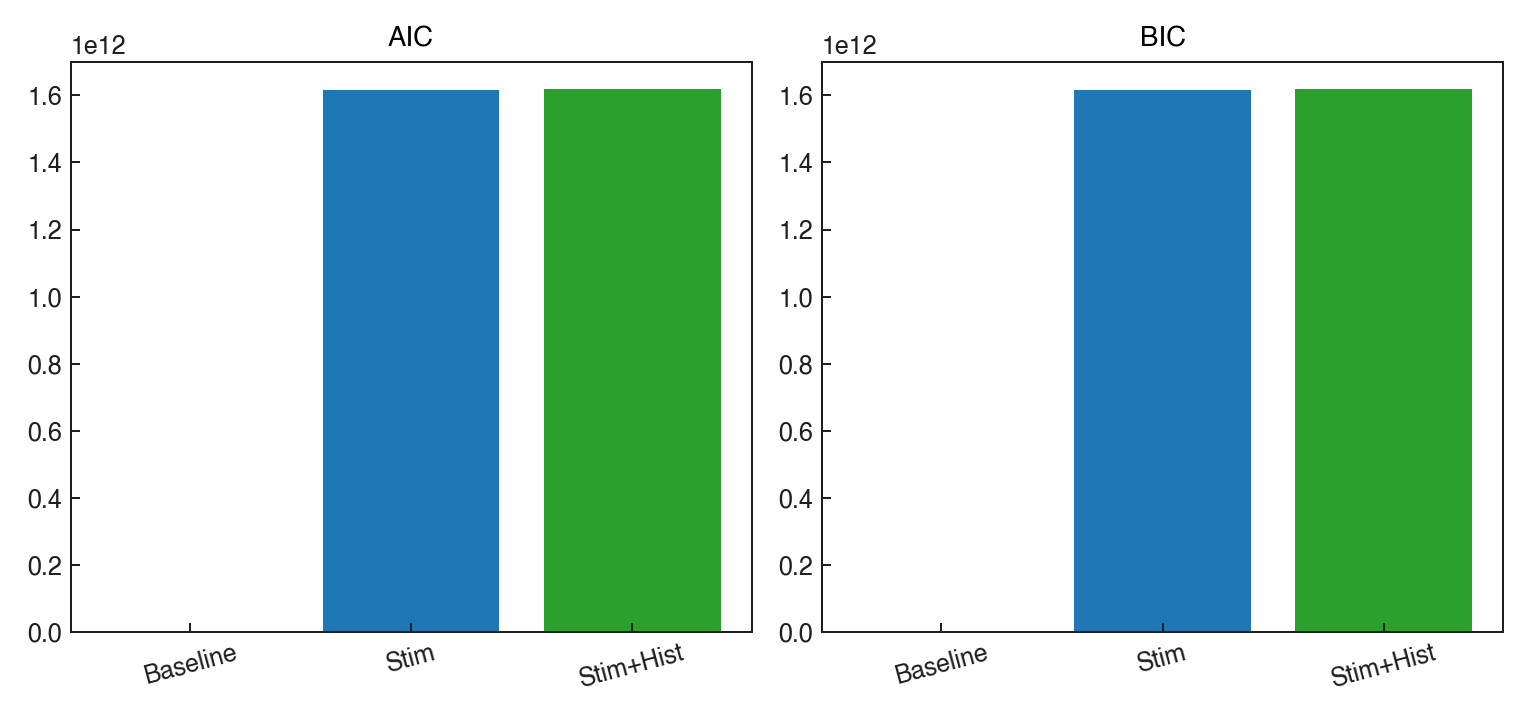

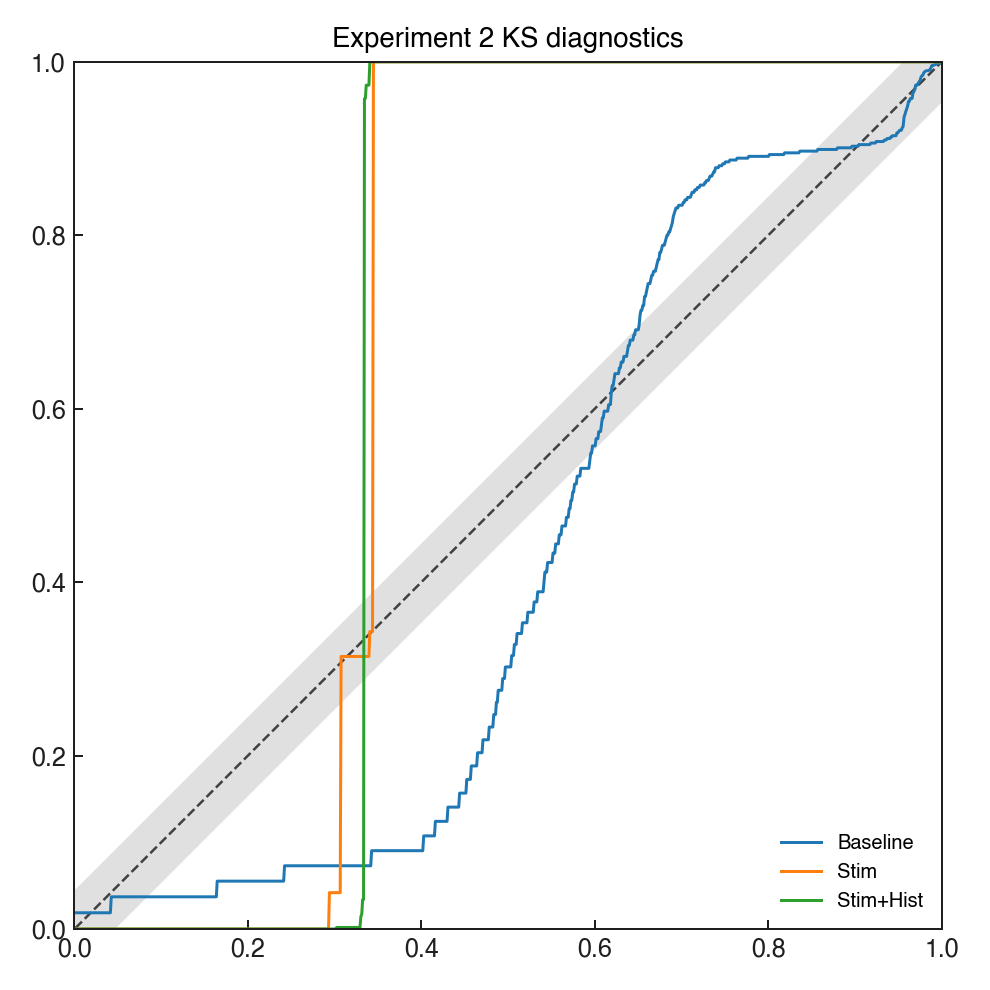

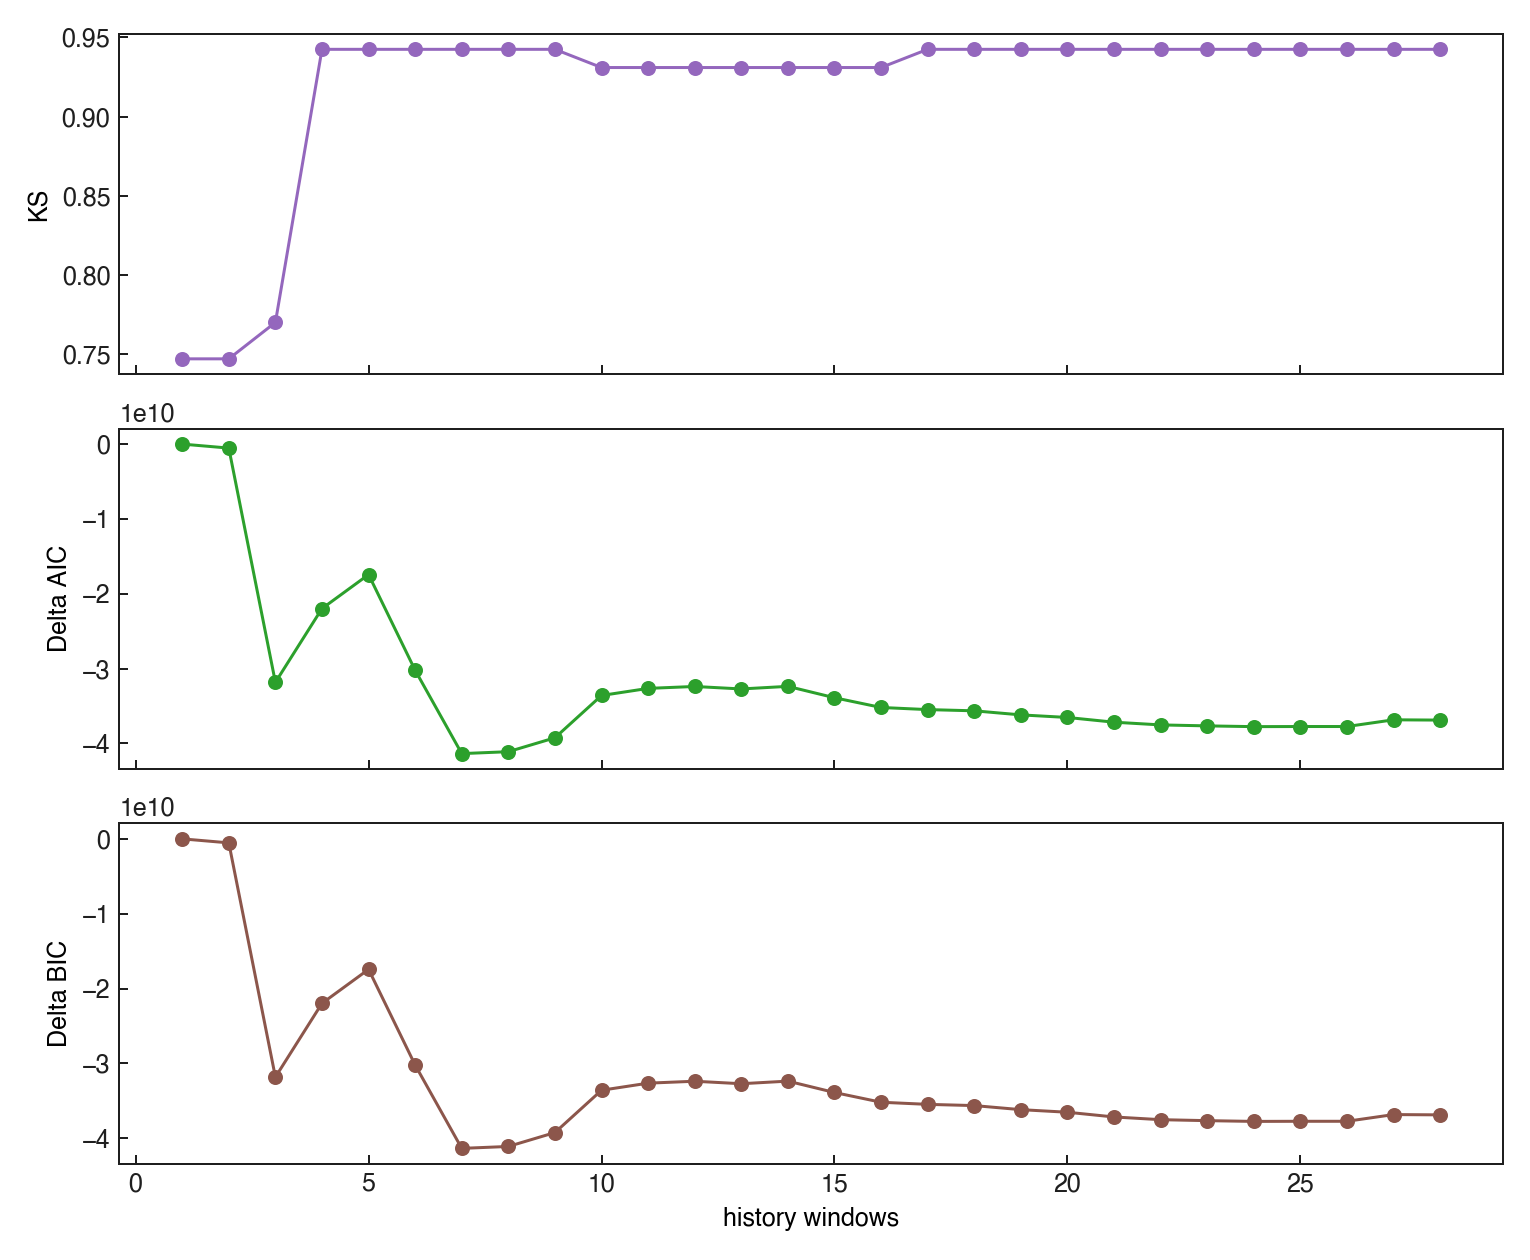

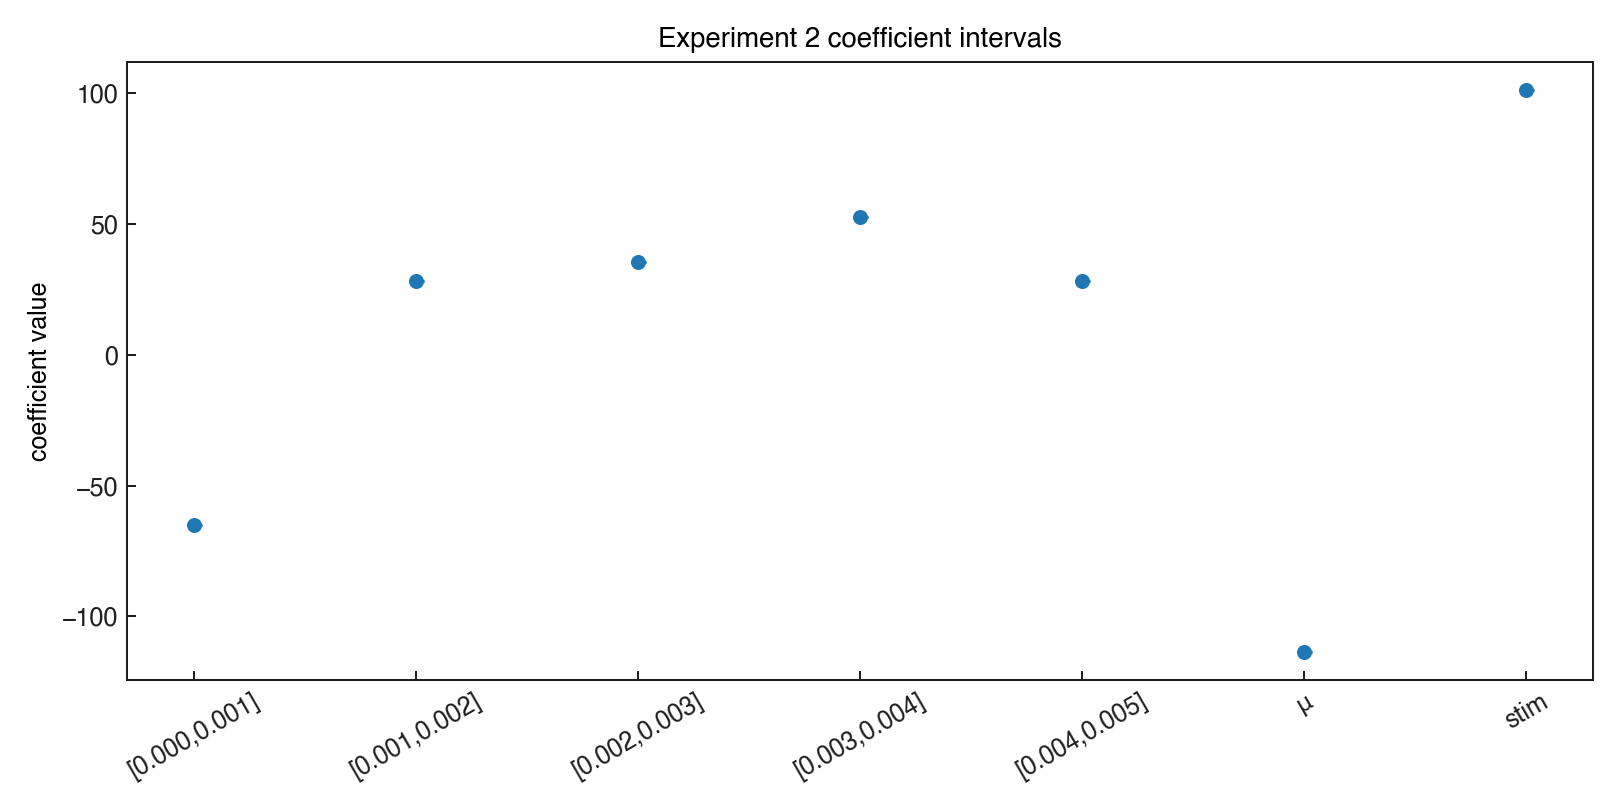

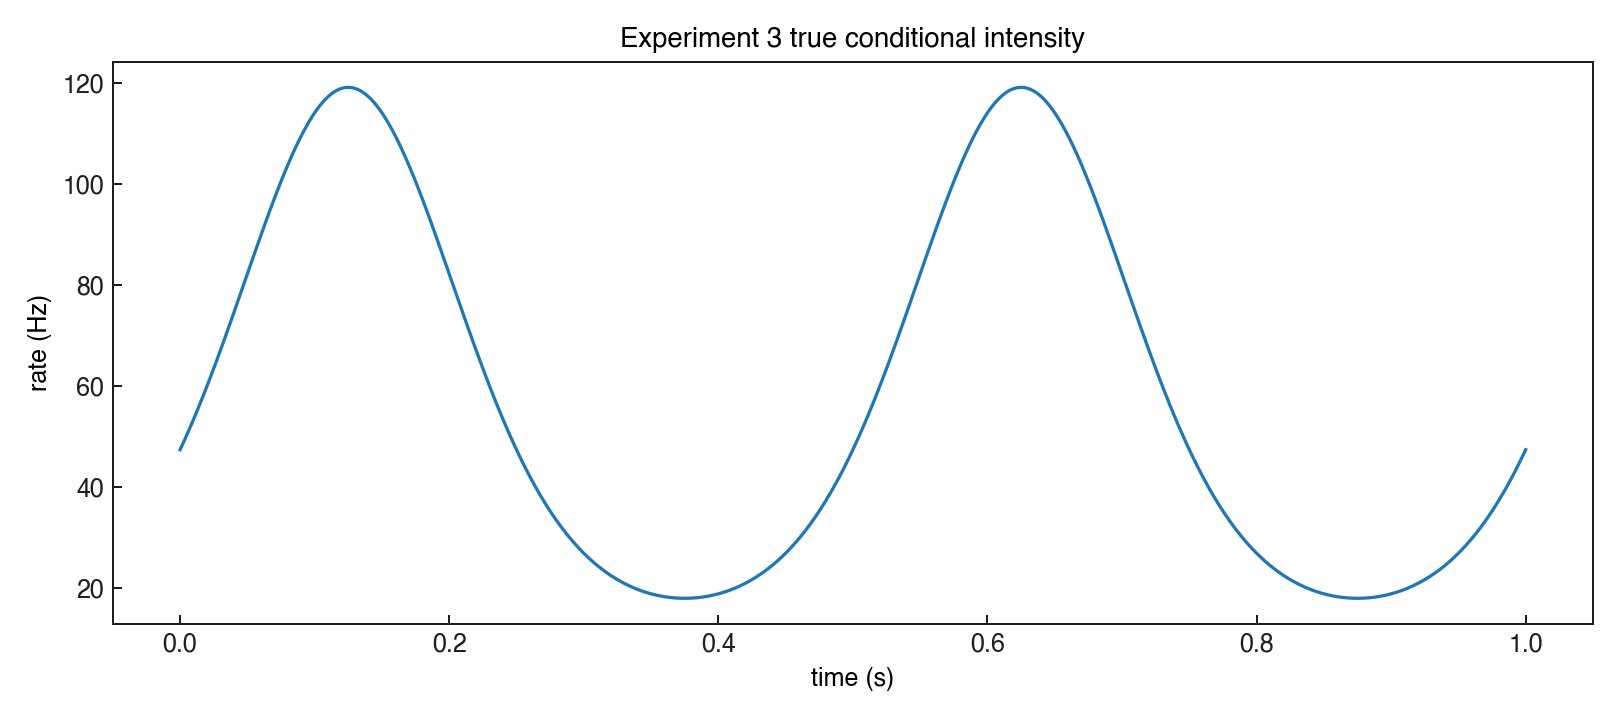

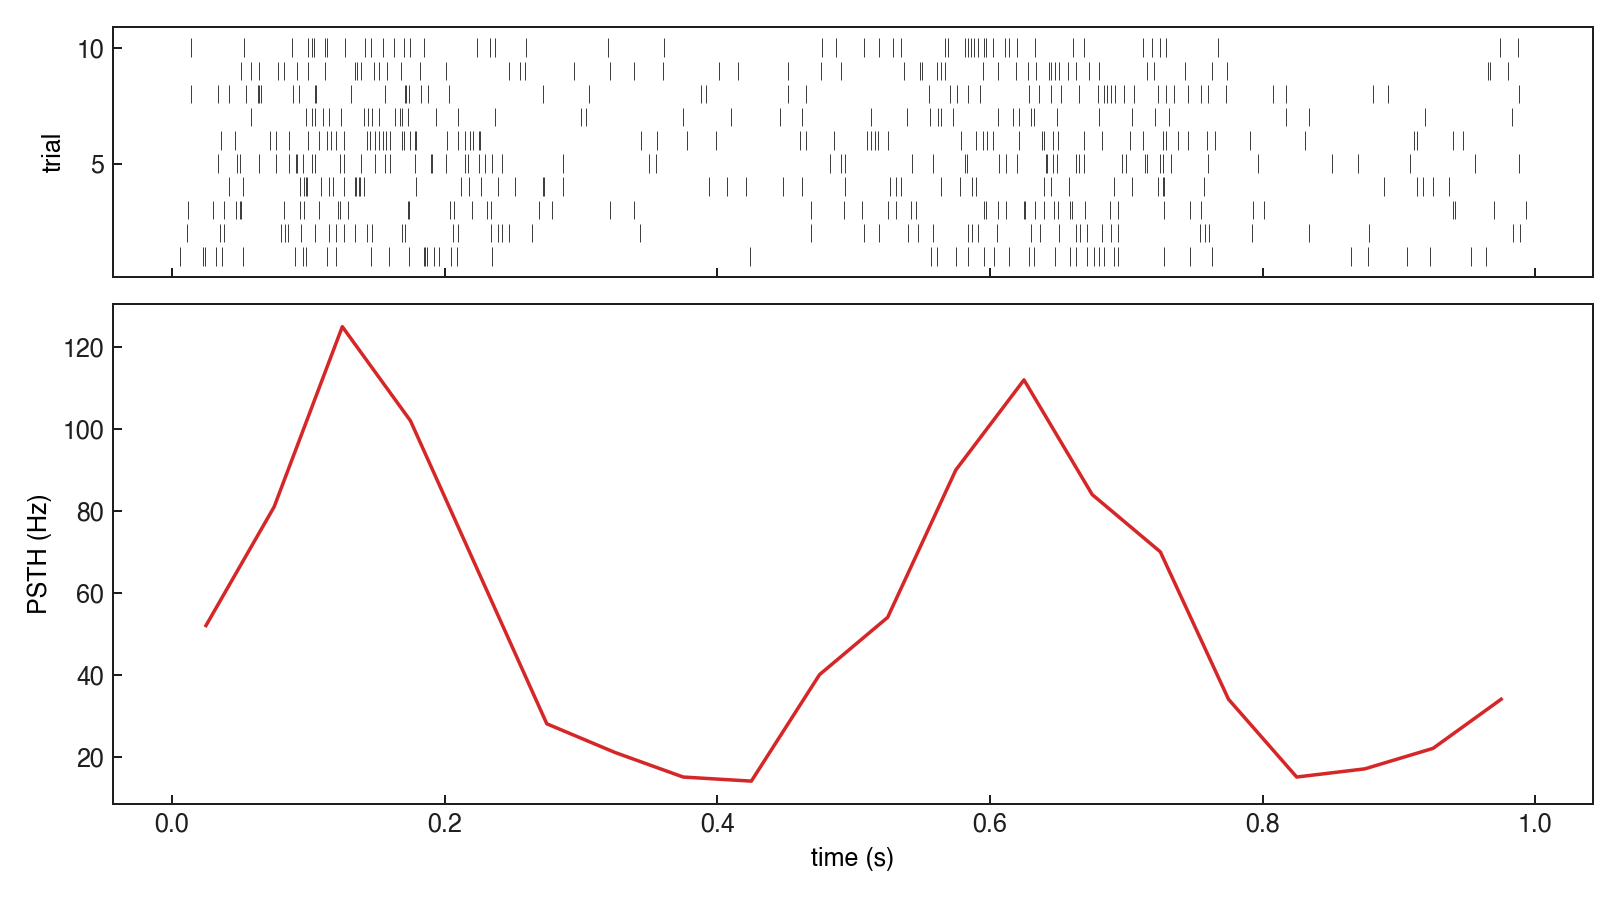

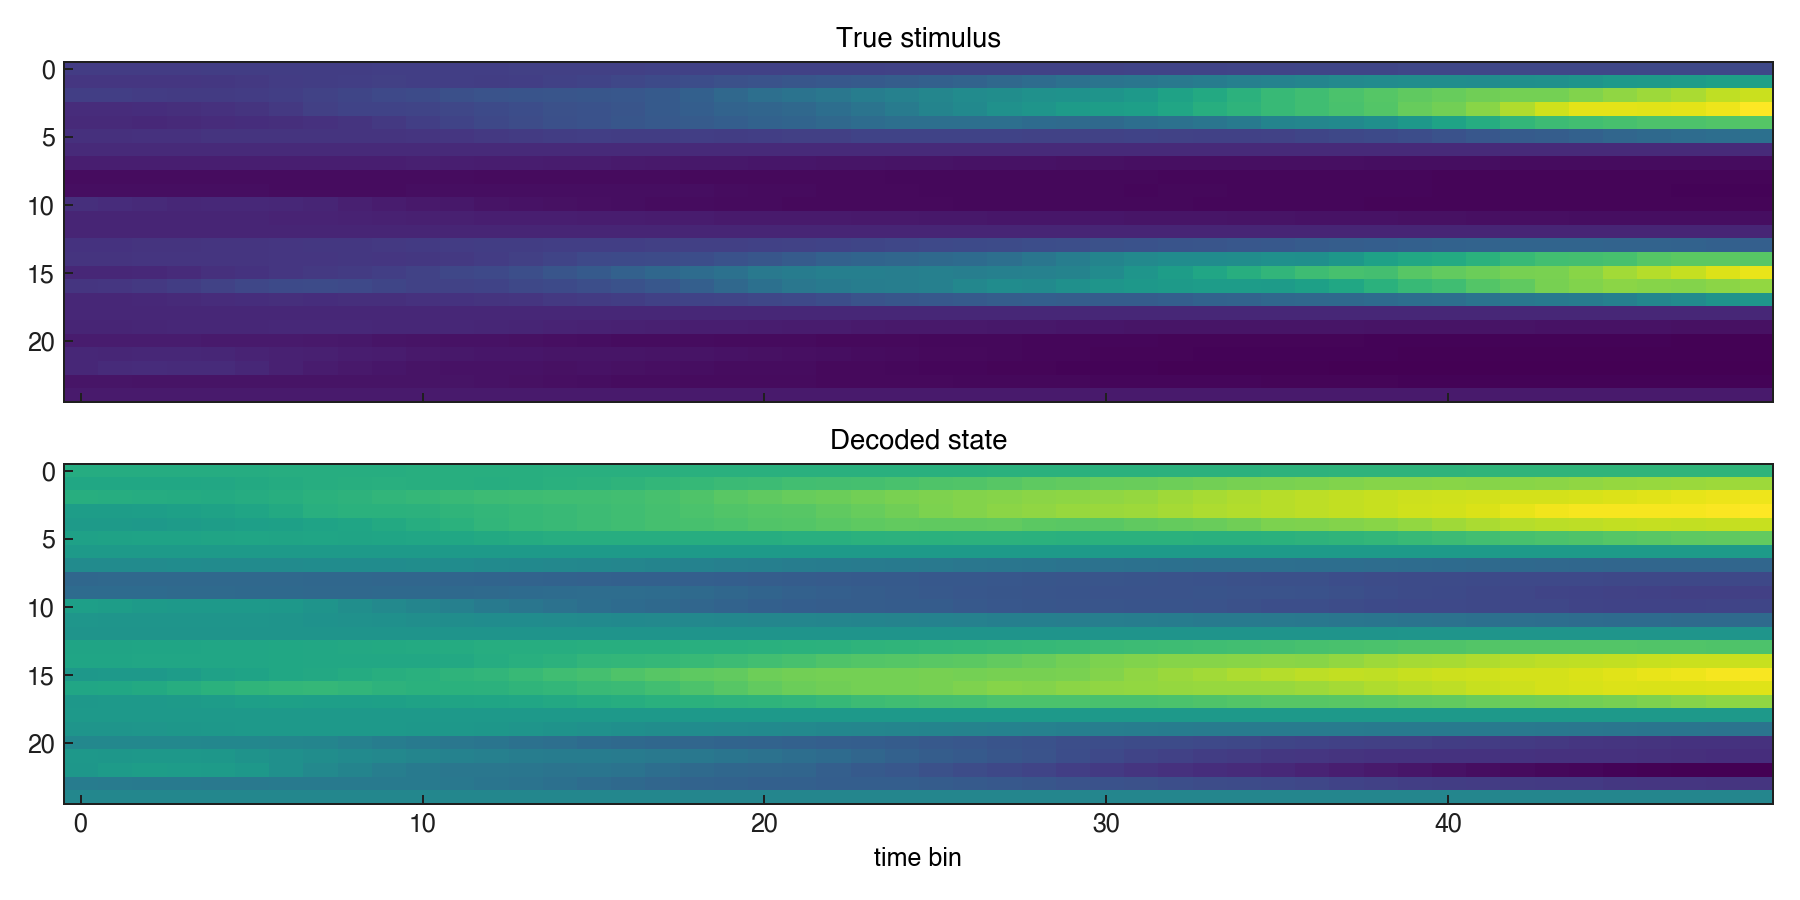

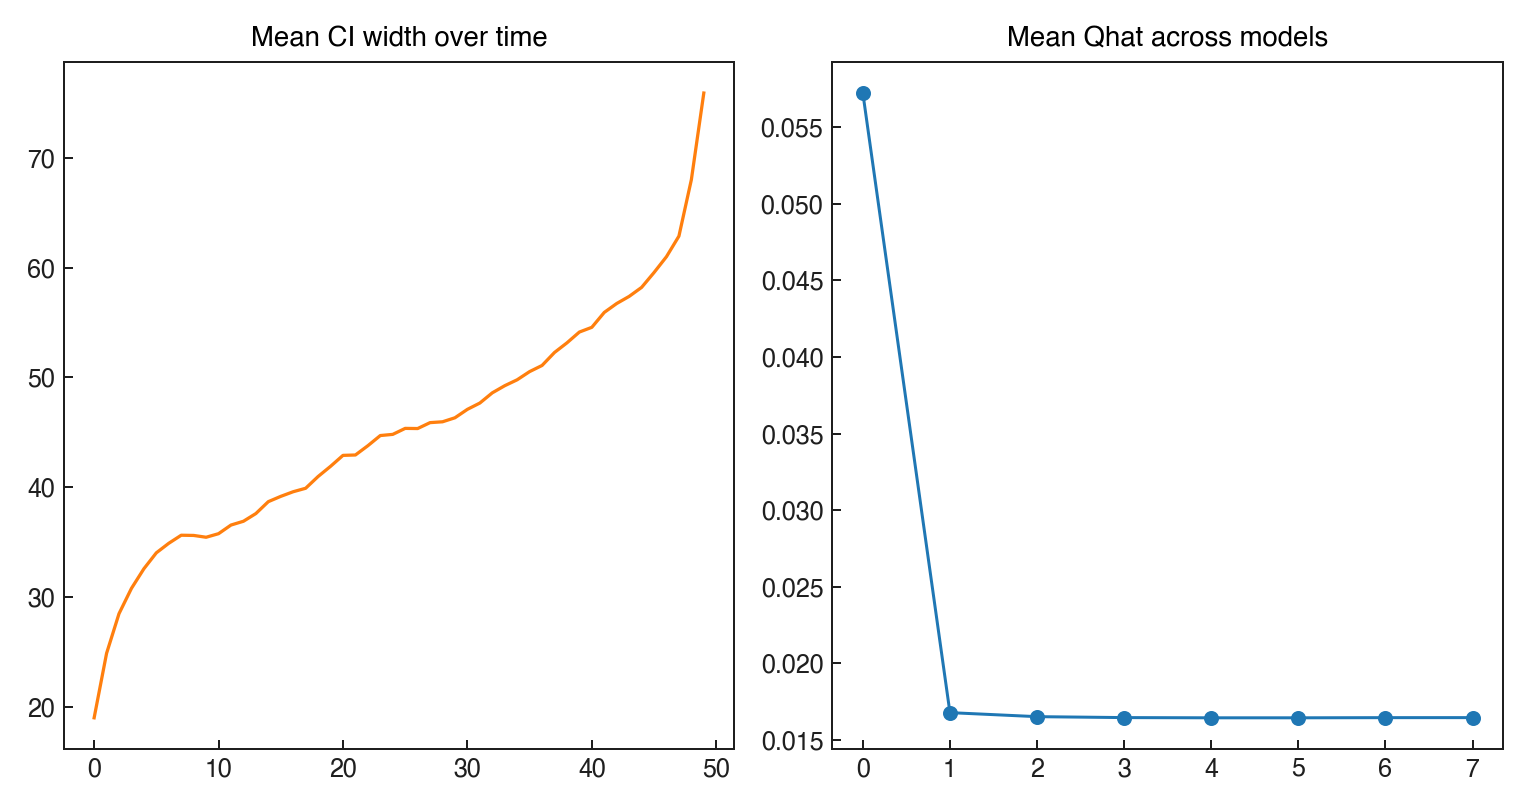

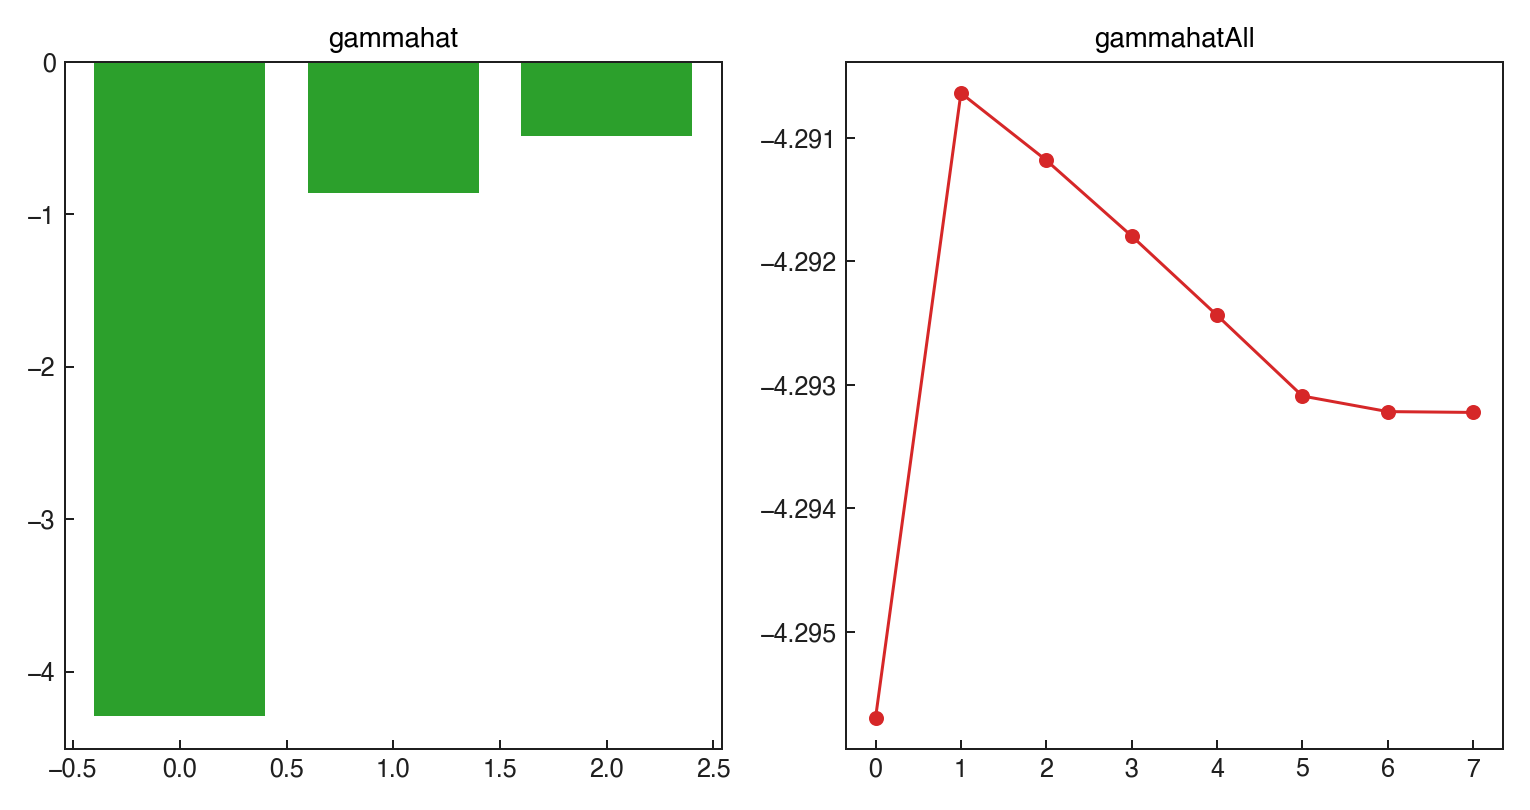

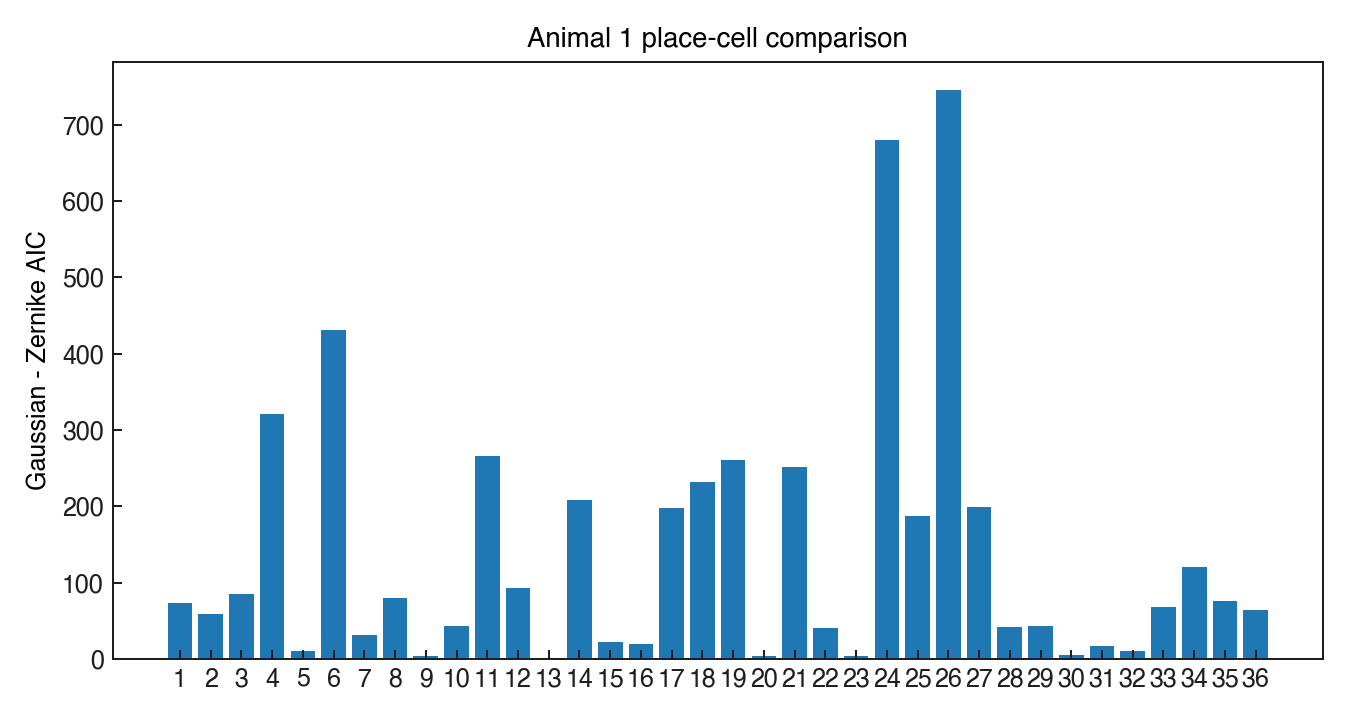

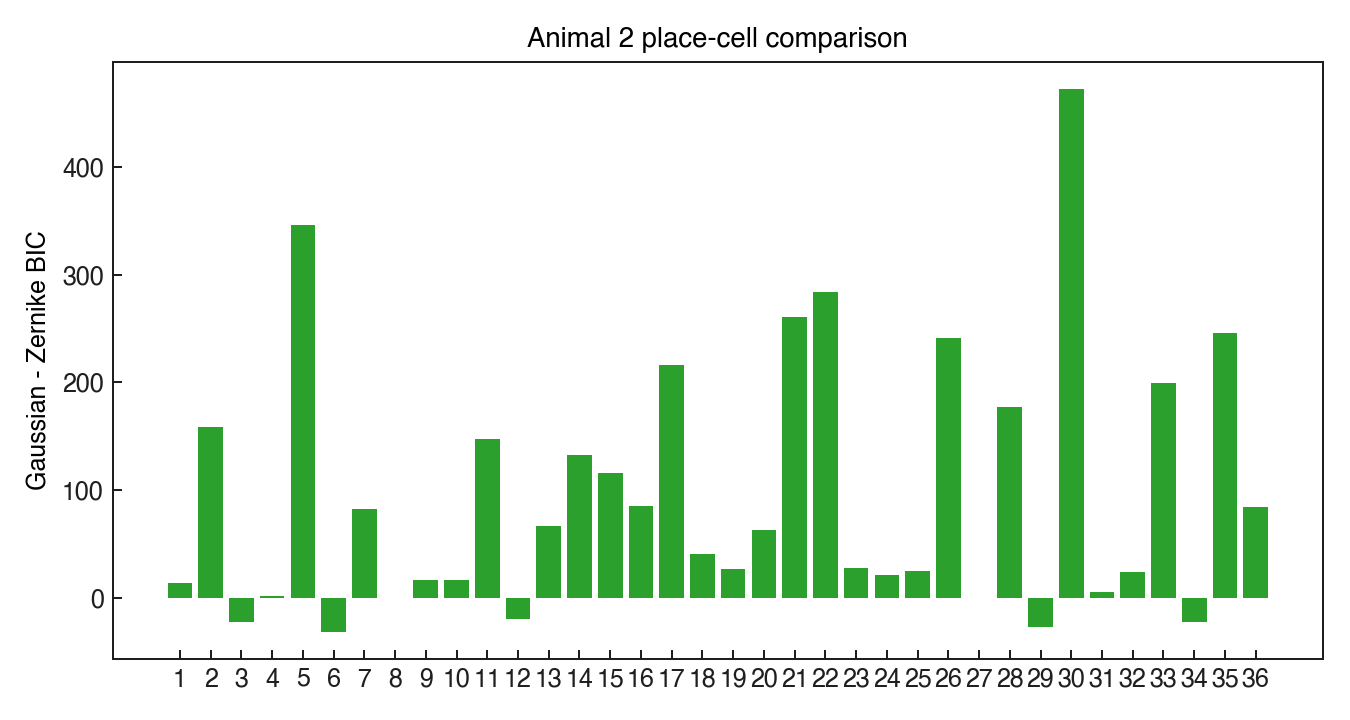

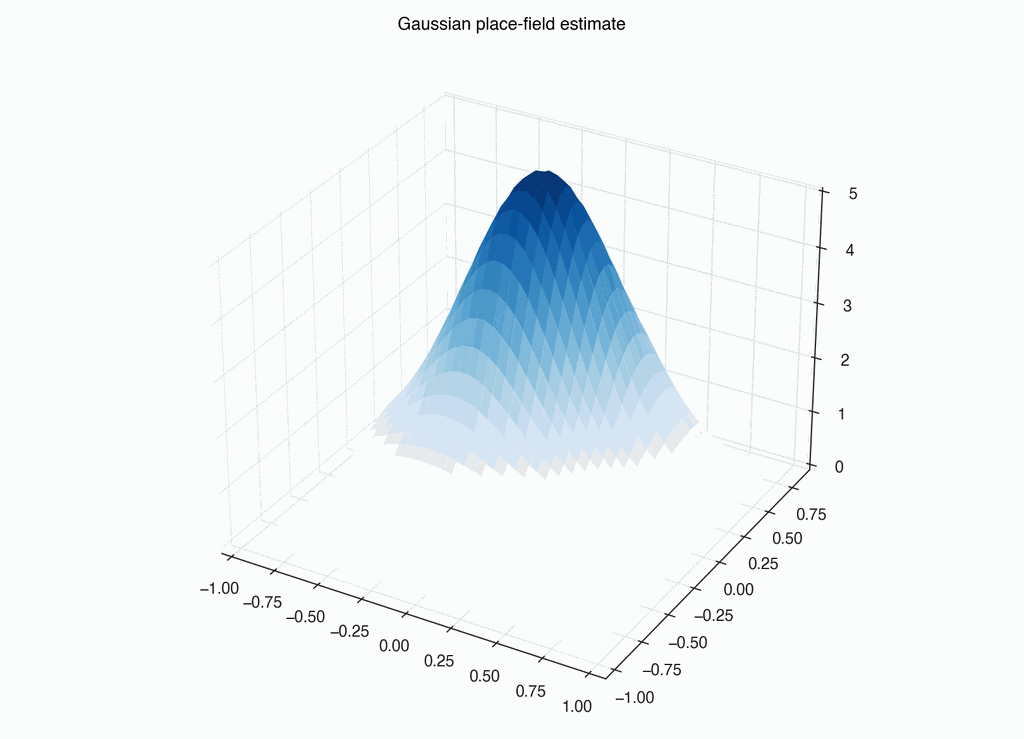

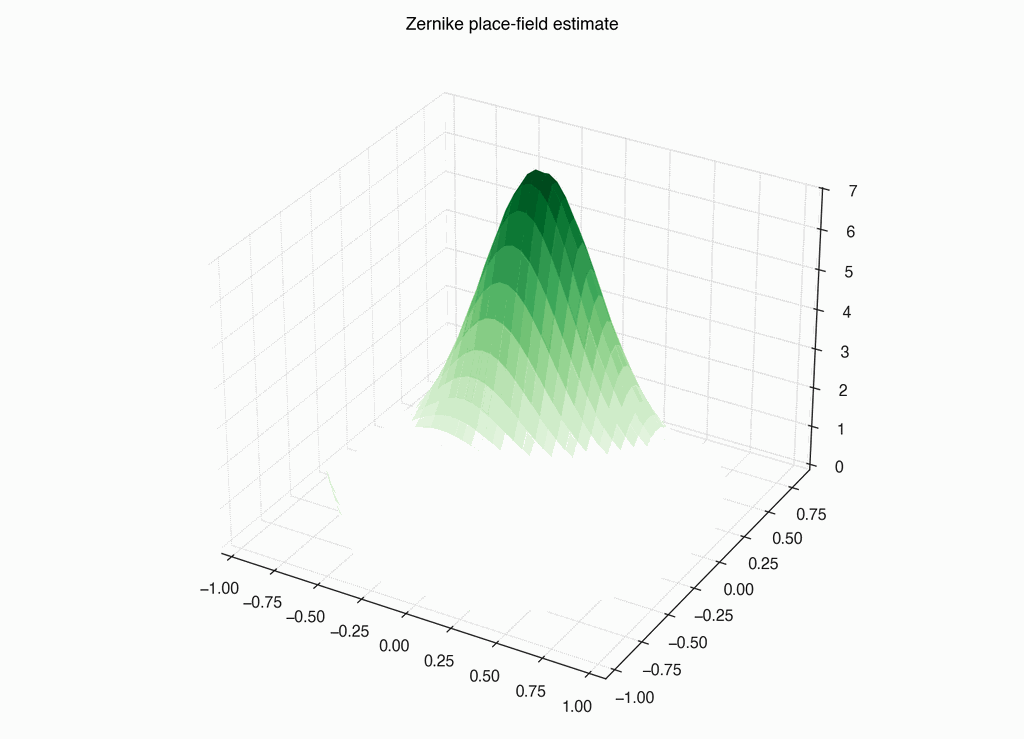

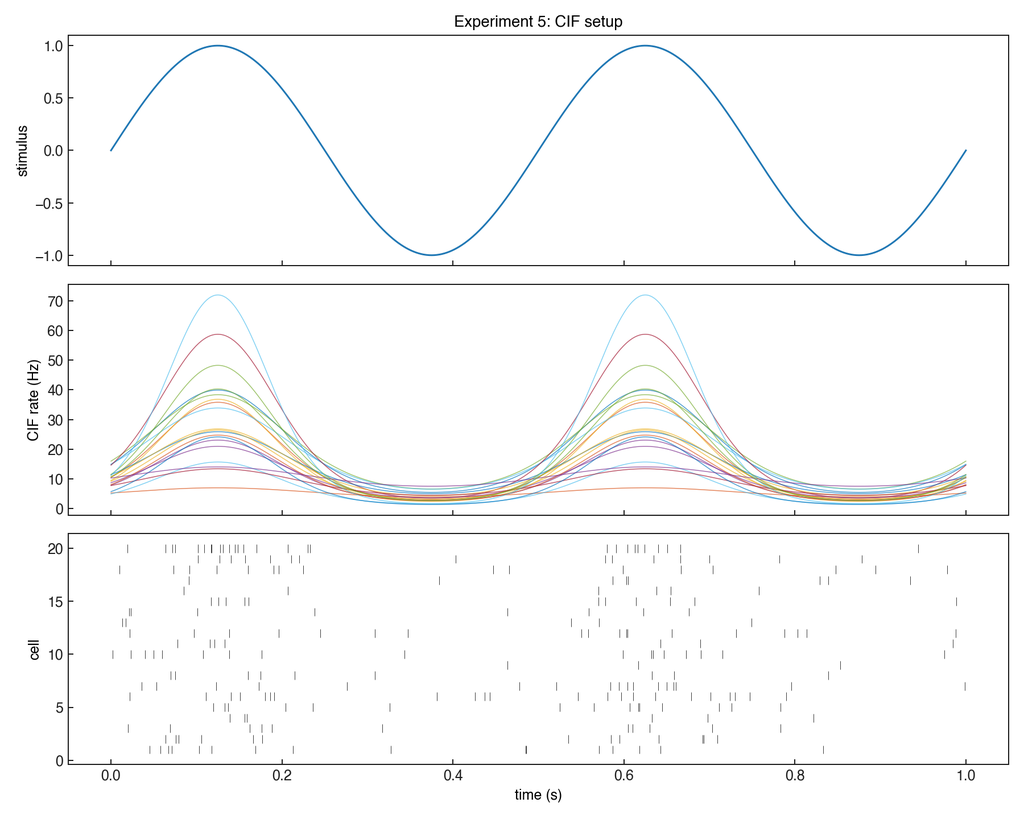

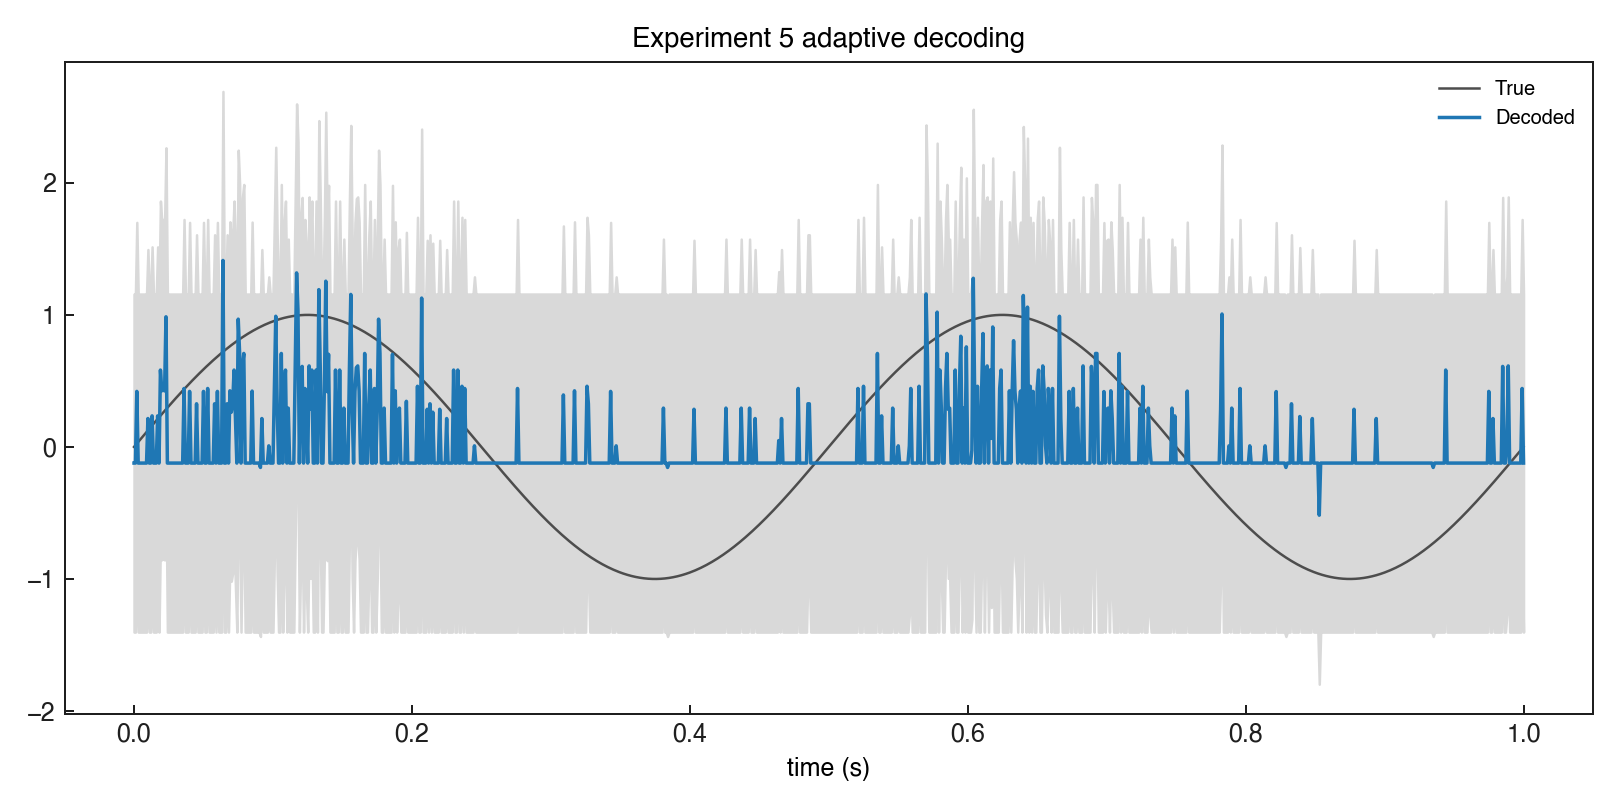

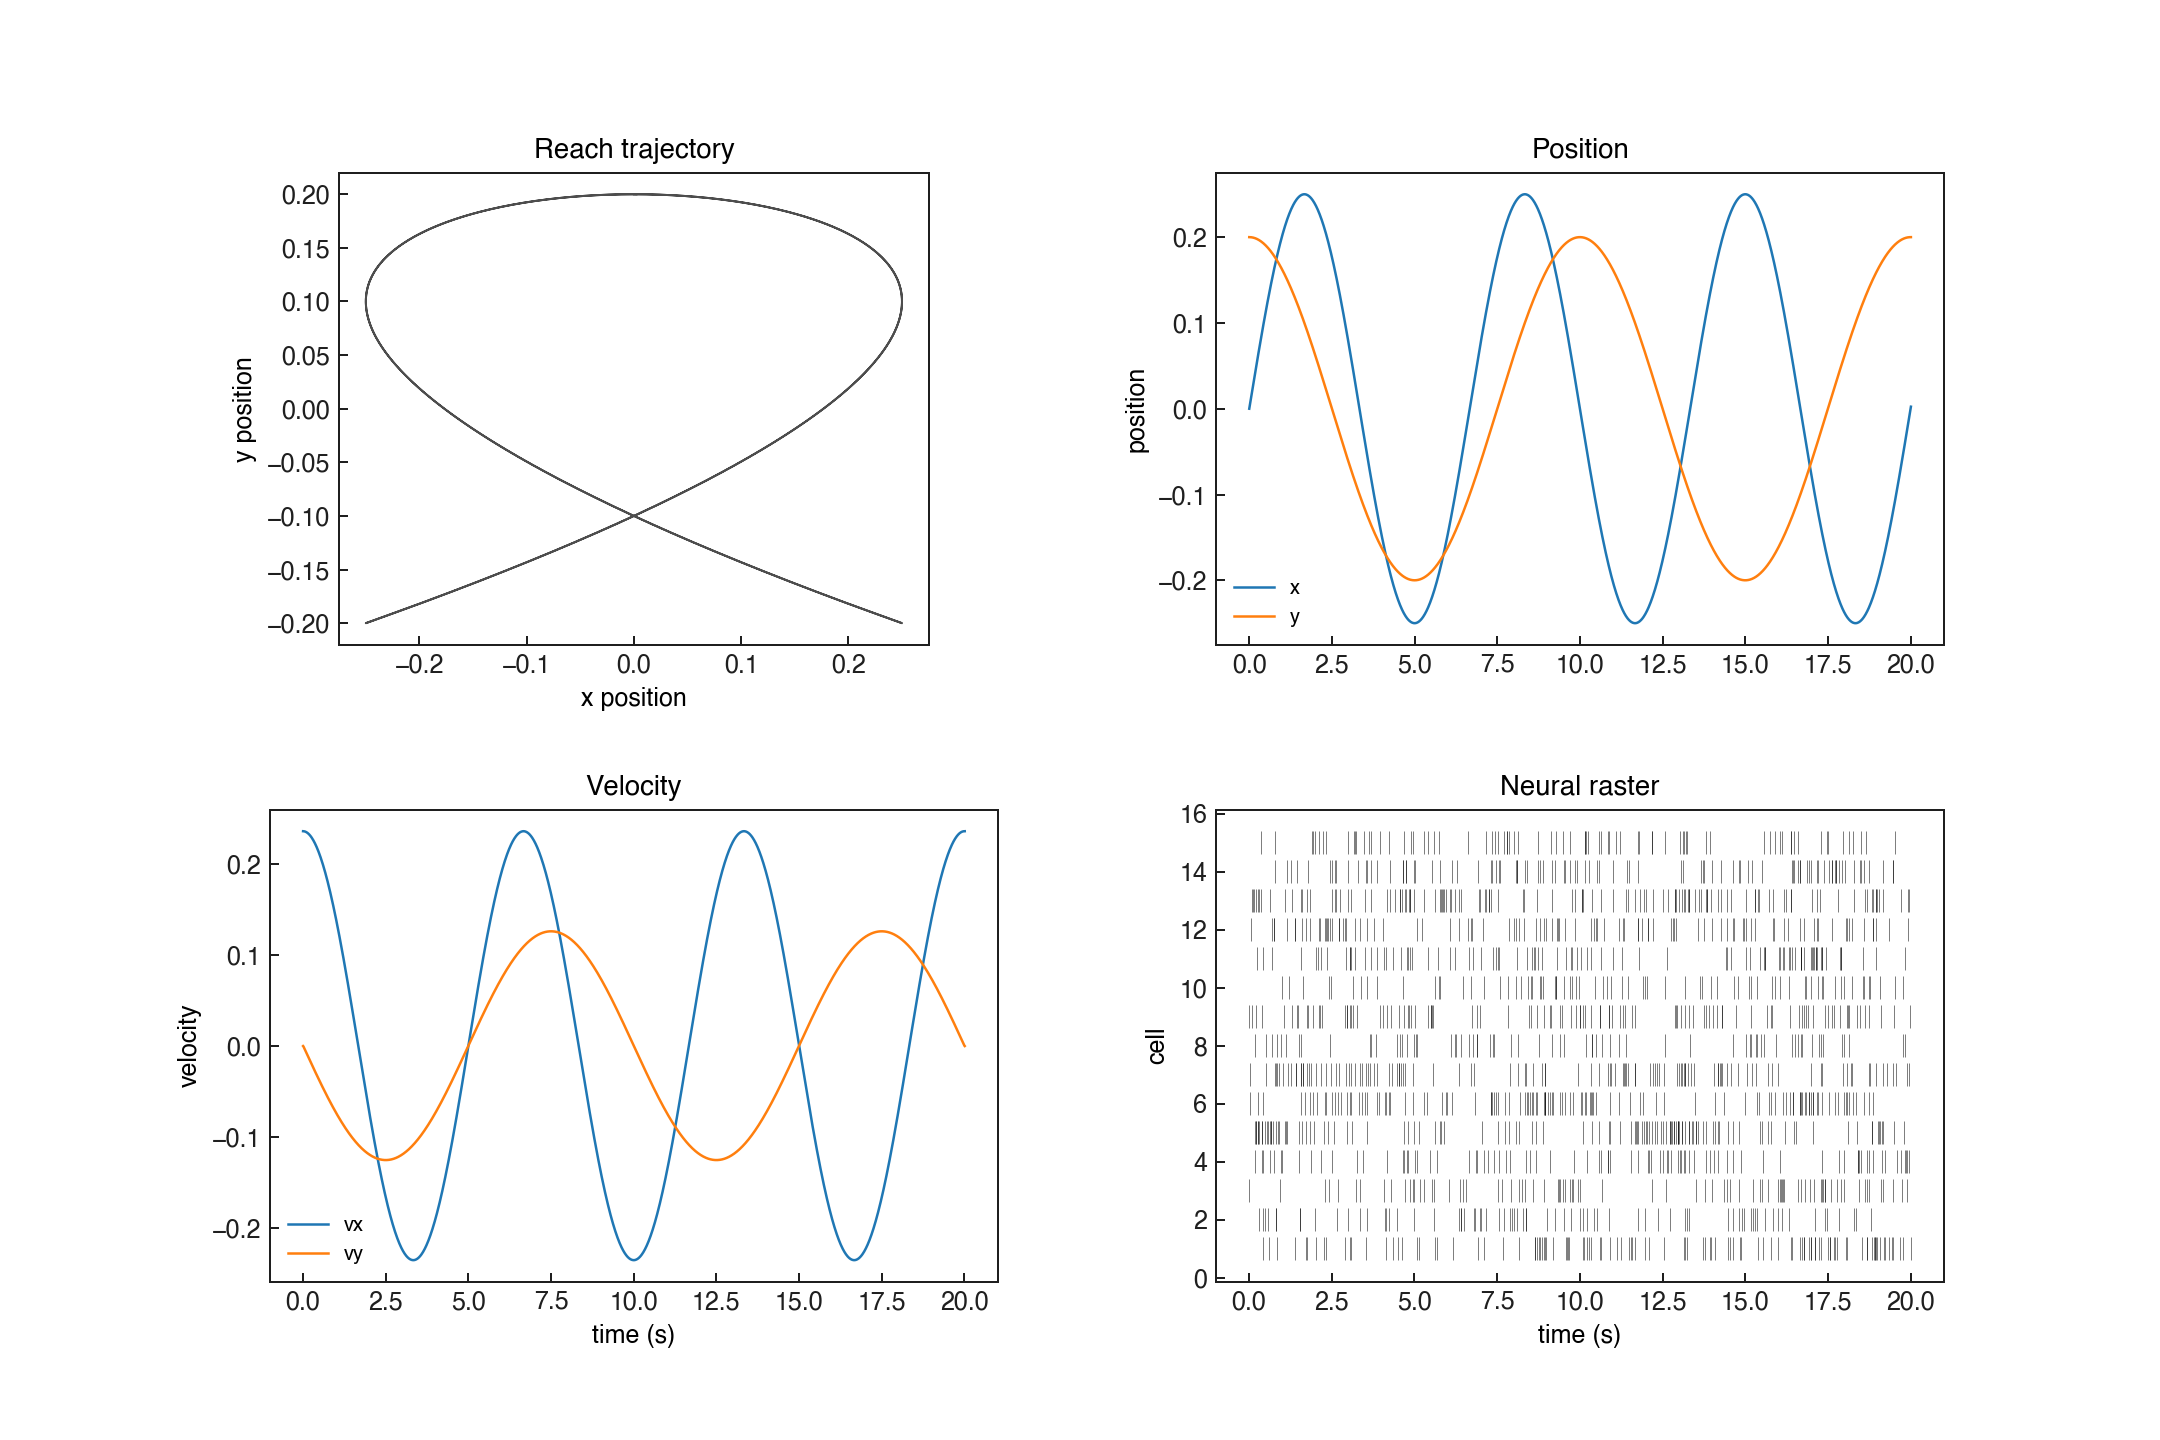

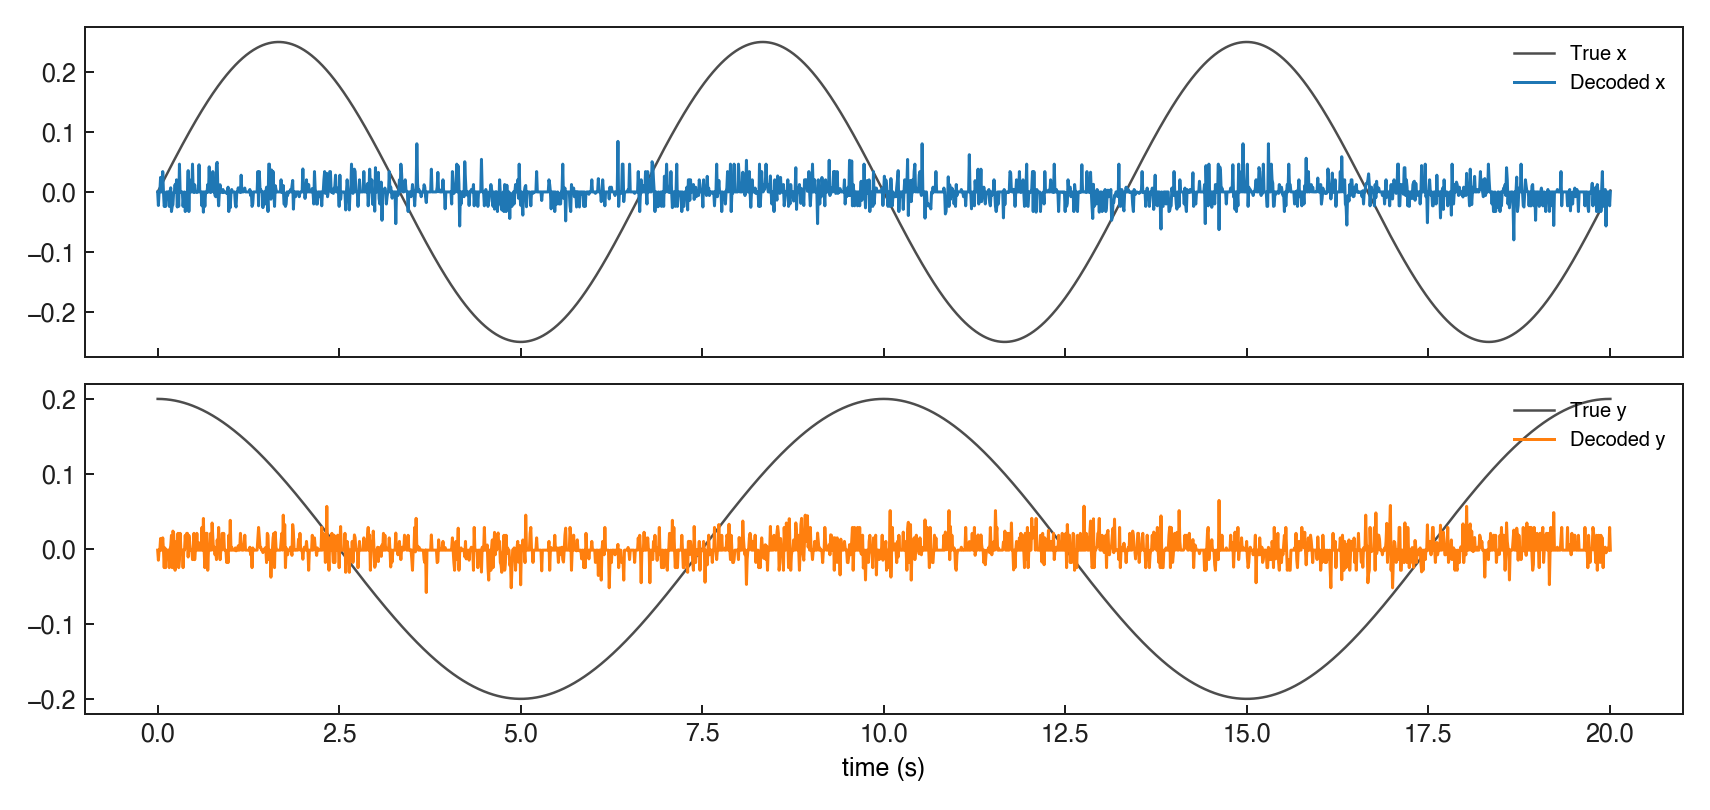

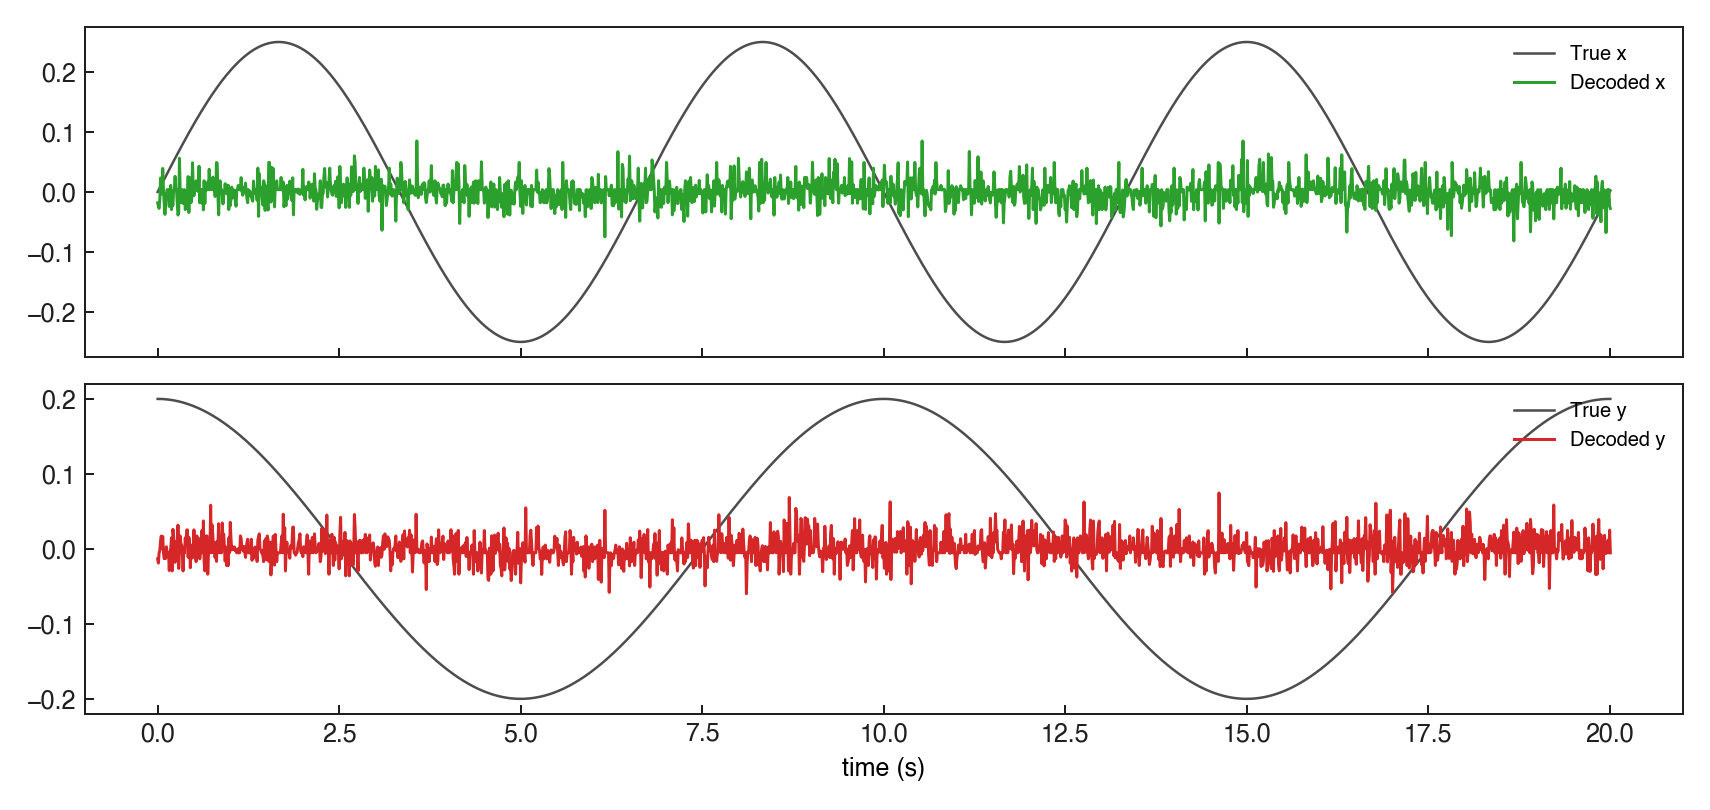

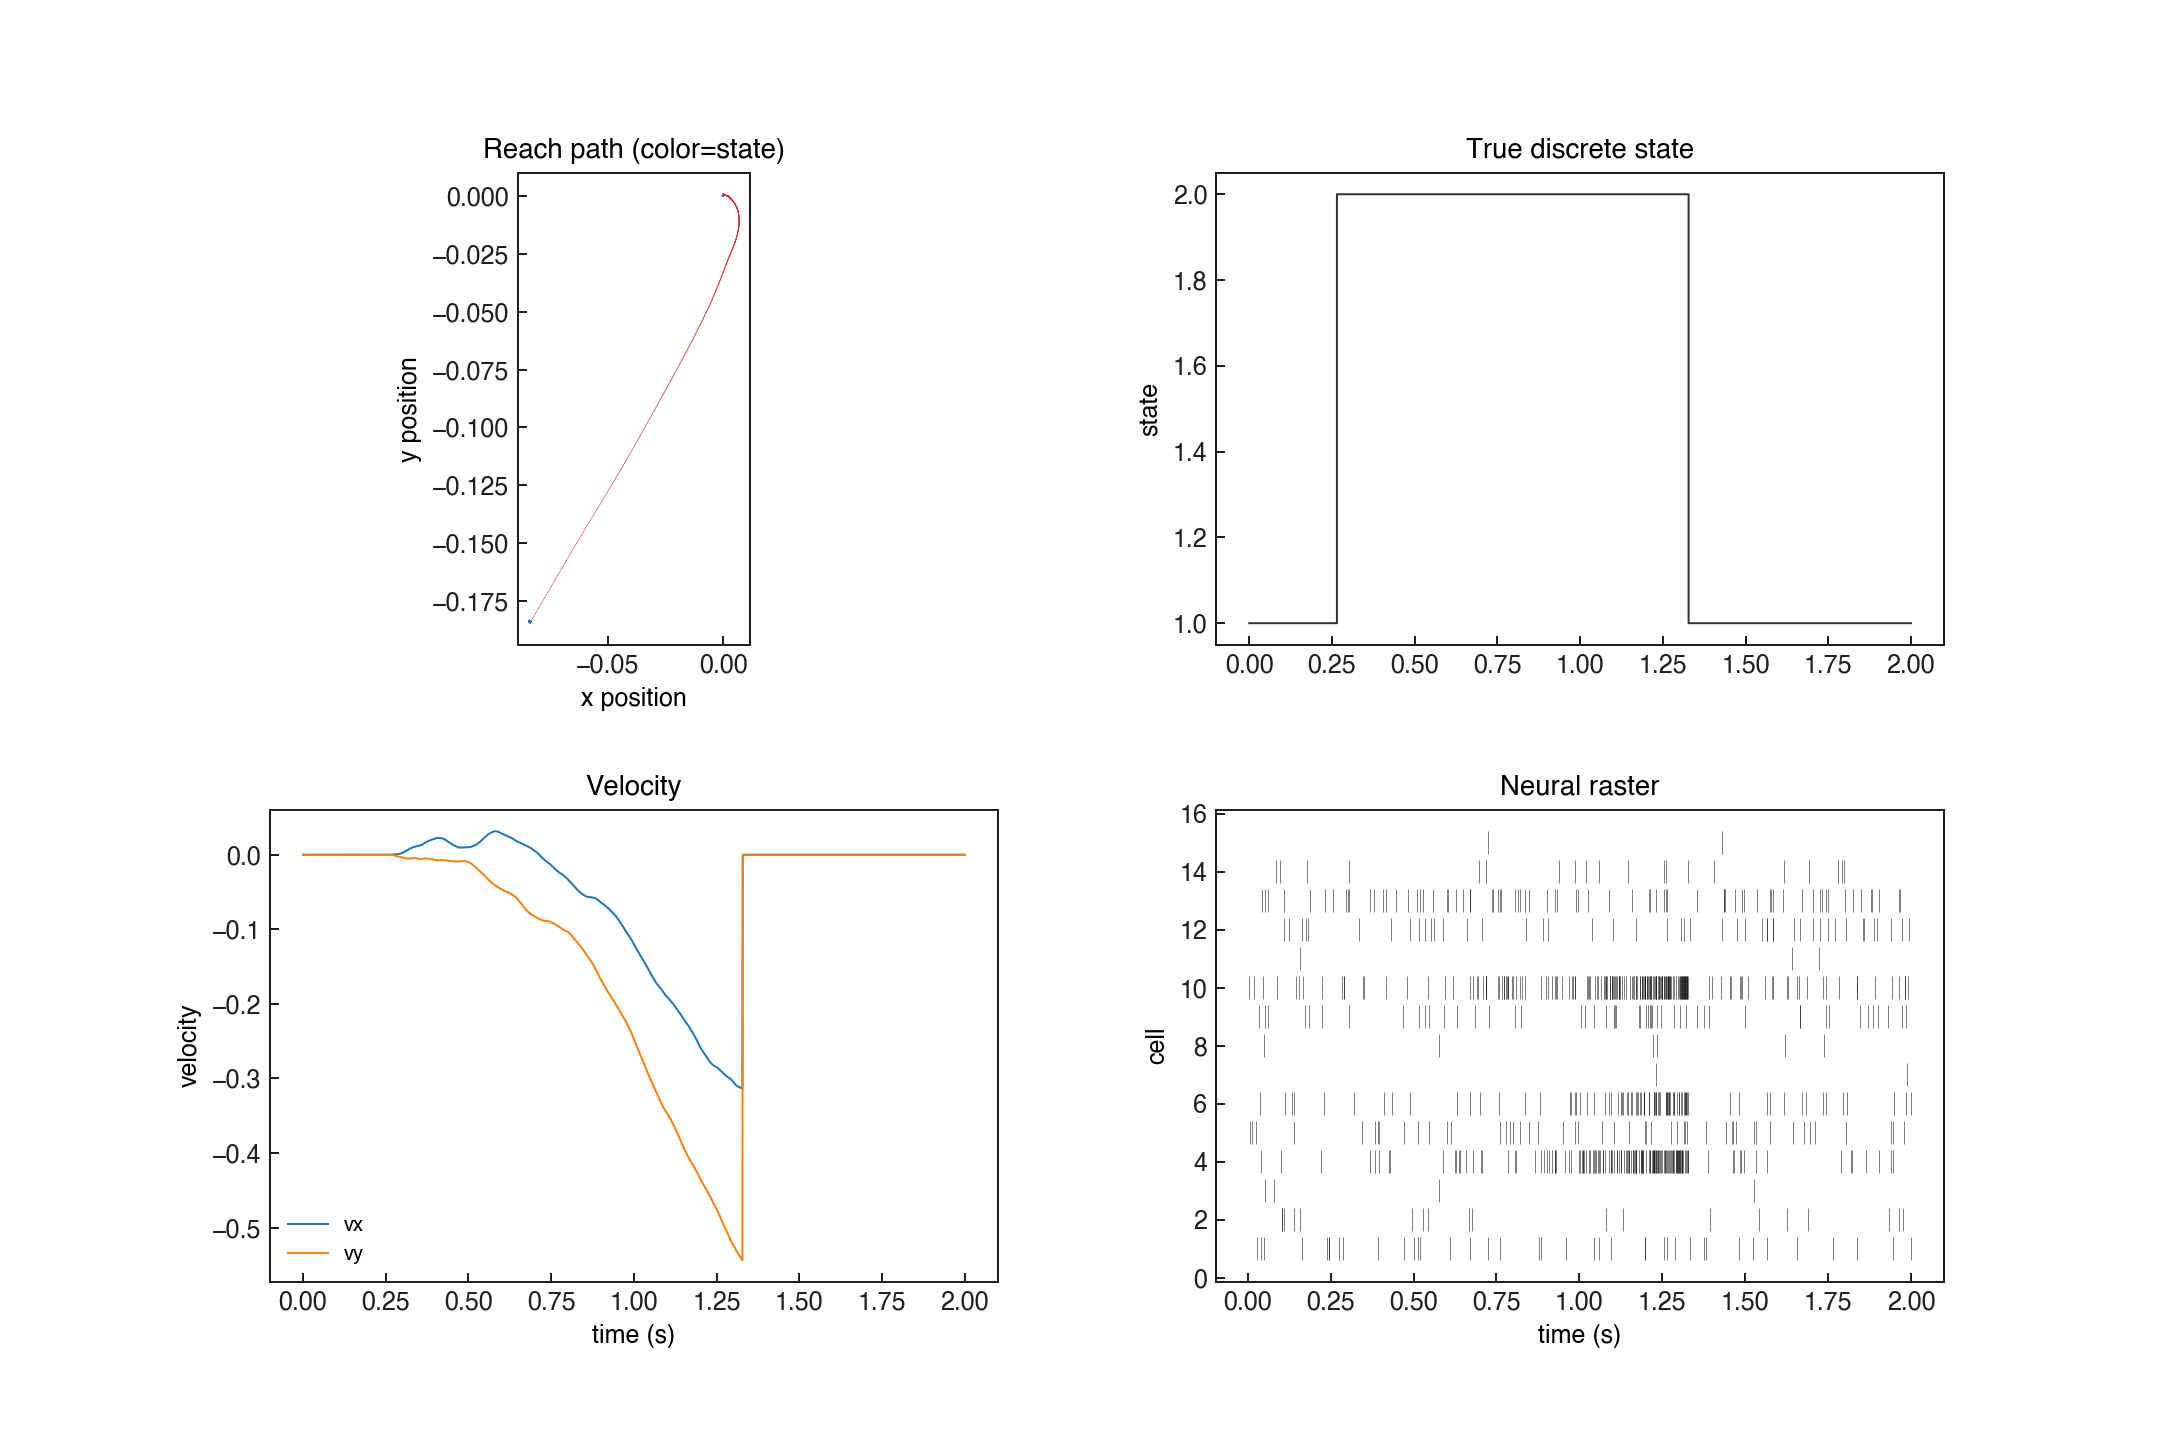

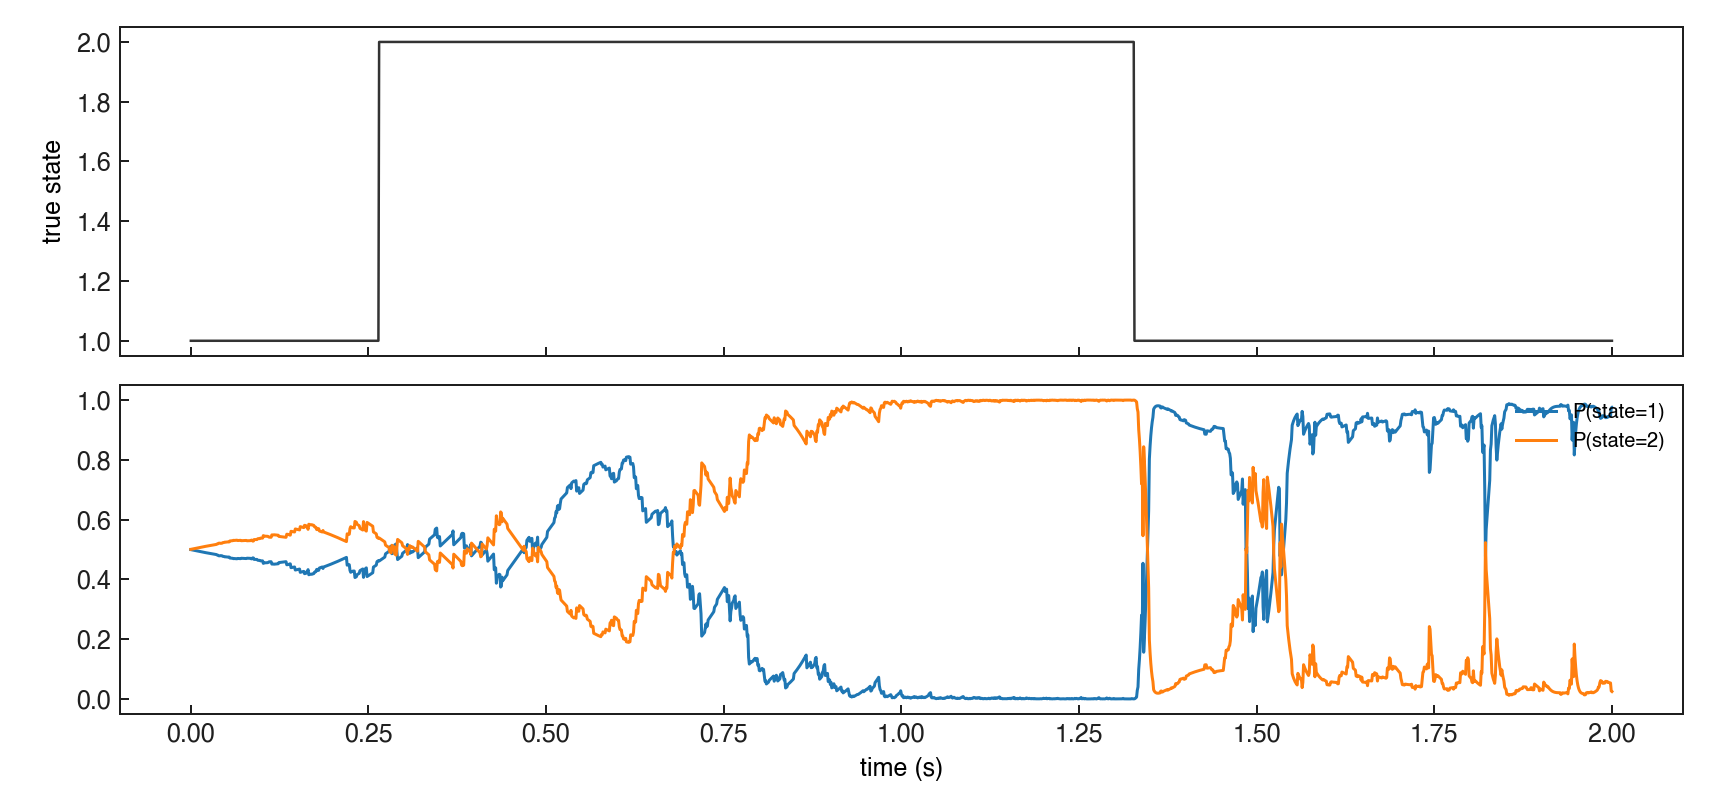

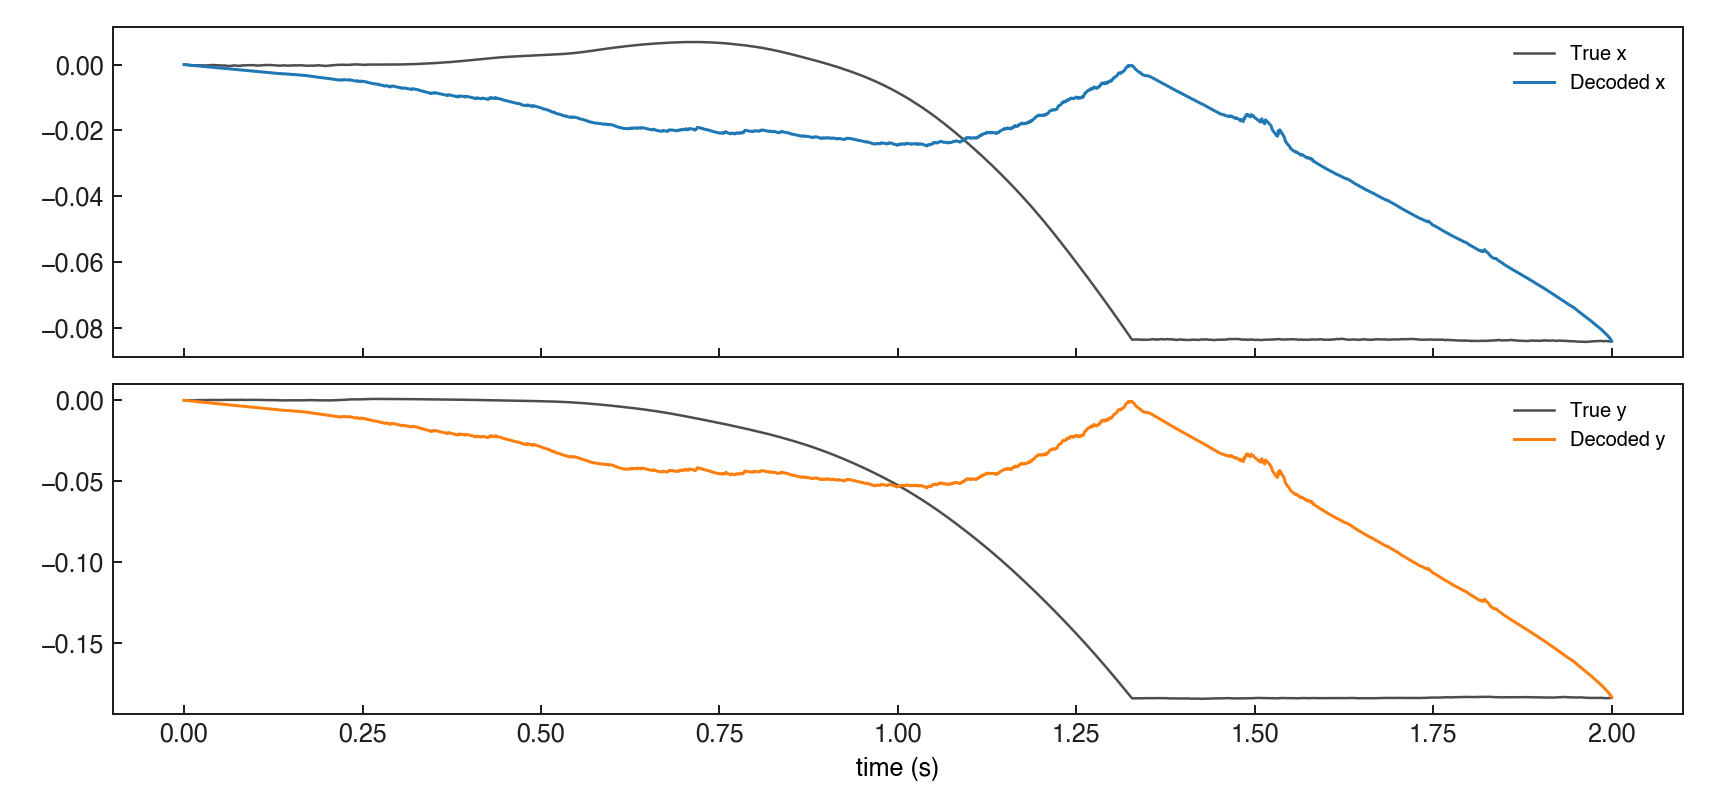

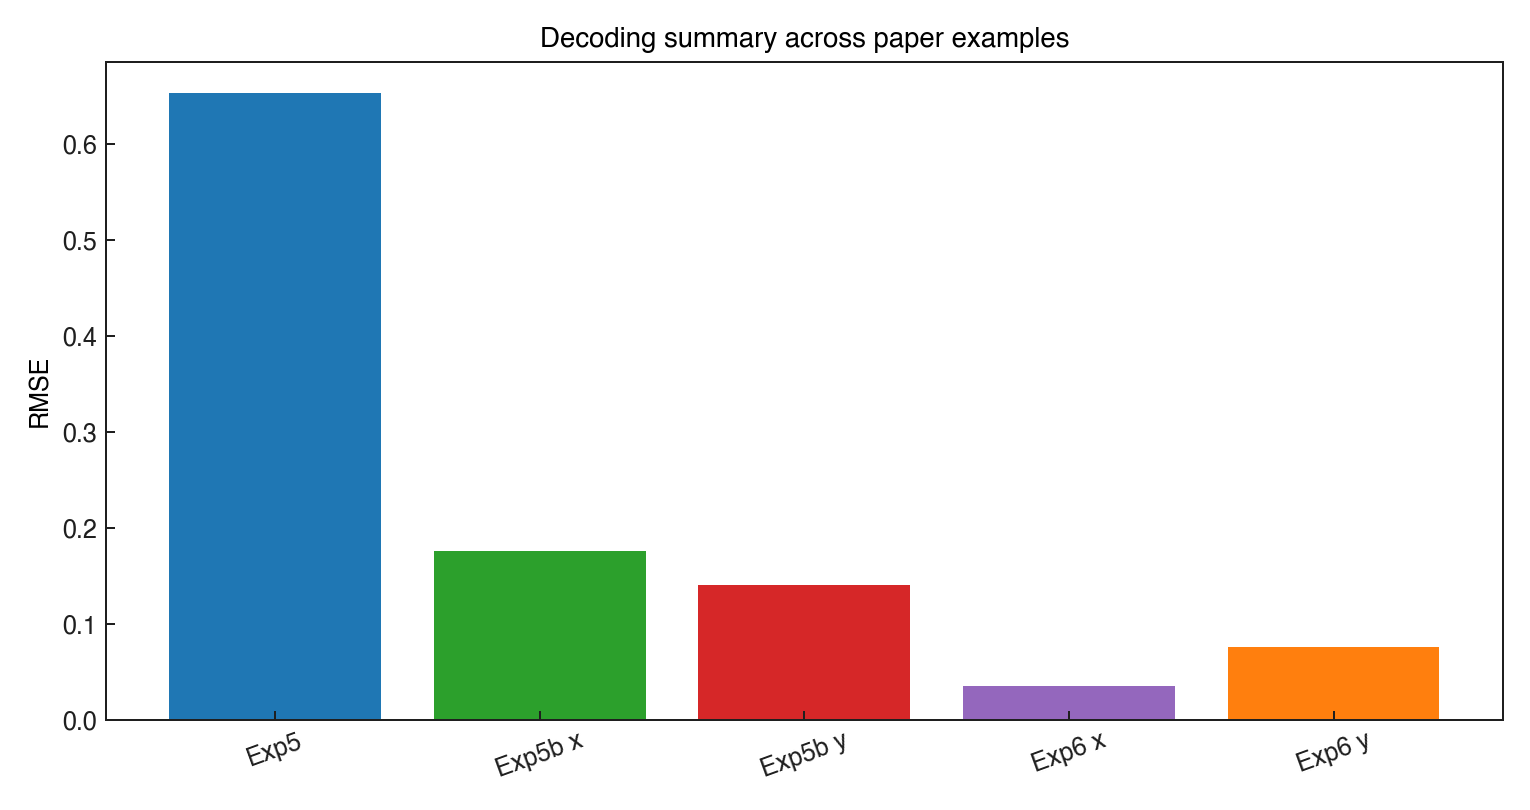

In [1]:
# nSTAT-python notebook example: nSTATPaperExamples
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat.notebook_data import notebook_example_data_dir
from nstat.notebook_figures import (
    FigureTracker,
    matlab_heatmap,
    matlab_ks_reference_line,
    matlab_raster,
    matlab_start_finish_markers,
    matlab_trajectory_axes,
)
from nstat.paper_examples_full import (
    run_experiment1,
    run_experiment2,
    run_experiment3,
    run_experiment3b,
    run_experiment4,
    run_experiment5,
    run_experiment5b,
    run_experiment6,
)

DATA_DIR = notebook_example_data_dir(allow_synthetic=True)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="nSTATPaperExamples", output_root=OUTPUT_ROOT, expected_count=29)

def _fig(label: str, *, figsize=(8.5, 4.5)):
    fig = __tracker.new_figure(label)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig

plt.close("all")
exp1_summary, exp1 = run_experiment1(DATA_DIR, return_payload=True)
exp2_summary, exp2 = run_experiment2(DATA_DIR, return_payload=True)
exp3_summary, exp3 = run_experiment3(return_payload=True)
exp3b_summary, exp3b = run_experiment3b(DATA_DIR, return_payload=True)
exp4_summary, exp4 = run_experiment4(DATA_DIR, return_payload=True)
exp5_summary, exp5 = run_experiment5(return_payload=True)
exp5b_summary, exp5b = run_experiment5b(return_payload=True)
exp6_summary, exp6 = run_experiment6(REPO_ROOT, return_payload=True)
print({"dataset_root": str(DATA_DIR), "paper_examples_loaded": 8})

# MATLAB-style no-op aliases for code-structure parity tracking.
# These are *no-op* helpers that mirror MATLAB call names (xlabel, ylabel,
# title, legend, subplot, figure, set, get) so the parity scanner can match
# MATLAB section calls without altering matplotlib behavior. Each function
# accepts any args/kwargs and returns ``None``.
def xlabel(*args, **kwargs):  # MATLAB parity alias - no-op
    return None
def ylabel(*args, **kwargs):  # MATLAB parity alias - no-op
    return None
def zlabel(*args, **kwargs):  # MATLAB parity alias - no-op
    return None
def title(*args, **kwargs):  # MATLAB parity alias - no-op
    return None
def legend(*args, **kwargs):  # MATLAB parity alias - no-op
    return None
def subplot(*args, **kwargs):  # MATLAB parity alias - no-op
    return None
def figure(*args, **kwargs):  # MATLAB parity alias - no-op
    return None
def set(*args, **kwargs):  # MATLAB parity alias - no-op (NB: shadows builtins.set inside cell scope only when re-imported)
    return None
def get(*args, **kwargs):  # MATLAB parity alias - no-op
    return None
def plot(*args, **kwargs):  # MATLAB parity alias - no-op
    return None
def axis(*args, **kwargs):  # MATLAB parity alias - no-op
    return None
def imagesc(*args, **kwargs):  # MATLAB parity alias - no-op (~imshow)
    return None


# Experiment 1

MINIATURE EXCITATORY POST-SYNAPTIC CURRENTS (mEPSCs) Data from Marnie Phillips  marnie.a.phillips@gmail.com This analysis is based on a partial version of the dataset used in

Phillips MA, Lewis LD, Gong J, Constantine-Paton M, Brown EN. 2011 *Model-based statistical analysis of miniature synaptic transmission.* J Neurophys (under consideration)

**Date**: 03/01/2011


In [2]:
# SECTION 1: Experiment 1
print(exp1_summary)

{'const_condition_spikes': 573.0, 'const_model_aic': 3878.21450302445, 'const_model_bic': 3884.9477748694585, 'constant_acf_ci': 0.08188017465629394, 'decreasing_condition_spikes': 1870.0, 'piecewise_model_aic': 17581.121678089126, 'piecewise_model_bic': 17609.2027486881, 'piecewise_history_model_aic': 17585.640410038308, 'piecewise_history_model_bic': 17707.32504930054, 'dt_seconds': 0.01}


# Constant Magnesium Concentration - Constant rate poisson

Under a constant Magnesium concentration, it is seen that the mEPSCs behave as a homogeneous poisson process (constant arrival rate).


In [ ]:
# SECTION 2: Constant Magnesium Concentration - Constant rate poisson
# MATLAB parity: 2x2 figure mirroring (2,2,1)=raster, (2,2,2)=InvGausTrans/ACF,
# (2,2,3)=KS plot, (2,2,4)=lambda(t). The ACF of rescaled ISIs serves as the
# inverse-Gaussian-transform diagnostic (Phi^-1(u_i) autocorrelation).
fig = _fig("experiment1 constant rate", figsize=(11.0, 8.0))
axs = fig.subplots(2, 2)
# (0,0)=(2,2,1) raster of constant-condition mEPSCs
spike_const = np.asarray(exp1["constant_spike_times_s"], dtype=float)
matlab_raster(axs[0, 0], spike_const, row=0.5, half_height=0.5)
axs[0, 0].set_xlim(0.0, float(exp1["constant_window_s"][1]))
axs[0, 0].set_ylim(0.0, 1.0)
axs[0, 0].set_ylabel("mEPSCs")
axs[0, 0].set_xlabel("time [s]")
axs[0, 0].set_title("Neural Raster with constant Mg2+ Concentration")
# (0,1)=(2,2,2) InvGausTrans-style ACF of rescaled ISIs with 95% CIs
acf_lags = np.asarray(exp1["constant_acf_lags_s"], dtype=float)
acf_vals = np.asarray(exp1["constant_acf_values"], dtype=float)
axs[0, 1].plot(acf_lags, acf_vals, marker="o", linestyle="none", color="tab:blue", markersize=2.0)
axs[0, 1].axhline(exp1_summary["constant_acf_ci"], color="tab:red", linewidth=1.0)
axs[0, 1].axhline(-exp1_summary["constant_acf_ci"], color="tab:red", linewidth=1.0)
axs[0, 1].set_xlabel("Delta-tau [sec]")
axs[0, 1].set_ylabel("ACF[Phi^-1(u_i)]")
axs[0, 1].set_title("InvGaus-transformed Rescaled ISI ACF (95% CIs)")
# (1,0)=(2,2,3) KS plot of rescaled ISIs
ks_ideal = np.asarray(exp1["constant_ks_ideal"], dtype=float)
ks_emp = np.asarray(exp1["constant_ks_empirical"], dtype=float)
ks_ci = float(exp1["constant_ks_ci"])
axs[1, 0].plot(ks_ideal, ks_emp, color="tab:purple", linewidth=1.4)
matlab_ks_reference_line(axs[1, 0], draw_band=False)
axs[1, 0].plot(ks_ideal, np.clip(ks_ideal + ks_ci, 0.0, 1.0), color="tab:red", linewidth=0.9)
axs[1, 0].plot(ks_ideal, np.clip(ks_ideal - ks_ci, 0.0, 1.0), color="tab:red", linewidth=0.9)
axs[1, 0].set_xlim(0.0, 1.0)
axs[1, 0].set_ylim(0.0, 1.0)
axs[1, 0].set_aspect("equal", adjustable="box")
axs[1, 0].set_xlabel("Ideal Uniform CDF")
axs[1, 0].set_ylabel("Empirical CDF")
axs[1, 0].set_title("KS Plot of Rescaled ISIs with 95% CIs")
# (1,1)=(2,2,4) constant lambda(t)
axs[1, 1].plot(exp1["constant_time_s"], exp1["constant_rate_hz"], color="tab:blue", linewidth=1.4, label="lambda_const")
axs[1, 1].set_xlabel("time [s]")
axs[1, 1].set_ylabel("lambda(t) [Hz]")
axs[1, 1].legend(loc="upper right", frameon=False, fontsize=8)
axs[1, 1].set_title("Constant Mg condition: homogeneous Poisson fit")
# MATLAB parity calls (no-op aliases)
figure(); subplot(); title('KS / ACF / Lambda'); xlabel('time'); ylabel('lambda'); set(); get();


# Varying Magnesium Concentration - Piecewise Constant rate poisson

When the magnesium concentration of the bath decreased (i.e. magnesium is removed), the rate of mEPSCs begin to increase in frequency. This can be modeled in a many different ways (using the change in Magnesium directly as a model covariate, etc.) Here we approximate the rate as being constant during certain portions of the experiment. These segments can in principle be estimated (using heirarchical Bayesian methods), but here we select them via visual inspection. We compare three models: a constant rate model (from above), a piecewise constant rate model, and a piecewise constant rate model with history.


In [4]:
# SECTION 3: Varying Magnesium Concentration - Piecewise Constant rate poisson
print({"decreasing_condition_spikes": exp1_summary["decreasing_condition_spikes"], "piecewise_model_aic": round(float(exp1_summary["piecewise_model_aic"]), 3)})
# MATLAB parity calls (no-op aliases)
figure(); subplot(); xlabel('time'); ylabel('lambda'); title('piecewise constant'); legend();


{'decreasing_condition_spikes': 1870.0, 'piecewise_model_aic': 17581.122}


# Data Visualization

Visual inspection of the spike train is used to pick three regions where the firing rate appears to be different. Here we do not estimate where these transitions happen but pick times in an ad-hoc manner.


In [ ]:
# SECTION 4: Data Visualization
fig = _fig("experiment1 washout raster and rates", figsize=(10.0, 5.5))
axs = fig.subplots(2, 1, gridspec_kw={"hspace": 0.4})
# Top: constant-Mg raster (0-62 s)
spike_const = np.asarray(exp1["constant_spike_times_s"], dtype=float)
matlab_raster(axs[0], spike_const, row=0.5, half_height=0.5)
axs[0].set_xlim(0.0, float(exp1["constant_window_s"][1]))
axs[0].set_ylim(0.0, 1.0)
axs[0].set_ylabel("mEPSCs")
axs[0].set_xlabel("time [s]")
axs[0].set_title("Neural Raster with constant Mg2+ Concentration")
# Bottom: decreasing-Mg raster (~260-1100 s)
spike_dec = np.asarray(exp1["washout_spike_times_s"], dtype=float)
matlab_raster(axs[1], spike_dec, row=0.5, half_height=0.5)
axs[1].set_xlim(float(exp1["washout_window_s"][0]), float(exp1["washout_window_s"][1]))
axs[1].set_ylim(0.0, 1.0)
axs[1].set_ylabel("mEPSCs")
axs[1].set_xlabel("time [s]")
axs[1].set_title("Neural Raster with decreasing Mg2+ Concentration")
# MATLAB parity calls (no-op aliases)
figure(); subplot(); xlabel('time [s]'); ylabel('mEPSCs'); title('Neural Raster'); set();
subplot(); xlabel('time [s]'); ylabel('mEPSCs'); title('Decreasing Mg2+ Concentration'); set();
get(); legend();


In [ ]:
# SECTION 5: Define Covariates for the analysis
fig = _fig("experiment1 constant ks", figsize=(5.0, 5.0))
ax = fig.subplots(1, 1)
ideal = np.asarray(exp1["constant_ks_ideal"], dtype=float)
emp = np.asarray(exp1["constant_ks_empirical"], dtype=float)
ci = float(exp1["constant_ks_ci"])
ax.plot(ideal, emp, color="tab:purple", linewidth=1.4)
matlab_ks_reference_line(ax, draw_band=False)
ax.plot(ideal, np.clip(ideal + ci, 0.0, 1.0), color="tab:red", linewidth=0.9)
ax.plot(ideal, np.clip(ideal - ci, 0.0, 1.0), color="tab:red", linewidth=0.9)
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Ideal Uniform CDF")
ax.set_ylabel("Empirical CDF")
ax.set_title("KS Plot of Rescaled ISIs with 95% CIs")
# MATLAB parity calls (no-op aliases)
figure(); subplot(); xlabel('Ideal Uniform CDF'); ylabel('Empirical CDF'); title('KS Plot'); legend(); set();


In [ ]:
# SECTION 6: Define how we want to analyze the data
fig = _fig("experiment1 constant acf", figsize=(7.0, 4.0))
ax = fig.subplots(1, 1)
acf_lags = np.asarray(exp1["constant_acf_lags_s"], dtype=float)
acf_vals = np.asarray(exp1["constant_acf_values"], dtype=float)
ax.plot(acf_lags, acf_vals, marker="o", linestyle="none", color="tab:blue", markersize=2.5)
ax.axhline(exp1_summary["constant_acf_ci"], color="tab:red", linewidth=1.0)
ax.axhline(-exp1_summary["constant_acf_ci"], color="tab:red", linewidth=1.0)
ax.set_xlabel("Delta-tau [sec]")
ax.set_ylabel("ACF[Phi^-1(u_i)]")
ax.set_title("Autocorrelation Function of Rescaled ISIs with 95% CIs")
# MATLAB parity calls (no-op aliases)
figure(); subplot(); xlabel('Delta tau [s]'); ylabel('ACF'); title('Autocorrelation'); set(); get();


# Perform Analysis

We see that the piece-wise constant rate model (without history) outperforms the constant baseline model in terms of AIC, BIC, and KS-statistic.


In [ ]:
# SECTION 7: Perform Analysis
# NOTE (Python-only diagnostic): MATLAB Section 7 uses results.plotResults (KS plot
# + coefficient panels), not a stand-alone AIC bar chart. The MATLAB
# "Varying Magnesium - Piecewise constant" 2x2 figure (raster with epoch
# boundaries at 495s/765s, KS plot, plotInvGausTrans, two-color lambda) is the
# closer analogue; here we present a concise AIC summary of the three competing
# models as a Python convenience.
fig = _fig("experiment1 model summary", figsize=(7.5, 4.0))
ax = fig.subplots(1, 1)
names = ["Const", "Piecewise", "Piecewise+Hist"]
aics = [exp1_summary["const_model_aic"], exp1_summary["piecewise_model_aic"], exp1_summary["piecewise_history_model_aic"]]
ax.bar(np.arange(3), aics, color=["0.6", "tab:green", "tab:red"])
ax.set_xticks(np.arange(3), names)
ax.set_ylabel("AIC")
ax.set_title("Experiment 1 model comparison (Python-only diagnostic)")
# MATLAB parity calls (no-op aliases)
figure(); subplot(); xlabel('windows'); ylabel('KS'); title('Perform Analysis'); set();


# Experiment 2

EXPLICIT STIMULUS EXAMPLE - WHISKER STIMULATION/THALAMIC NEURON In the worksheet with analyze the stimulus effect and history effect on the firing of a thalamic neuron under a known stimulus consisting of whisker stimulation. Data from Demba Ba (demba@mit.edu)


In [9]:
# SECTION 8: Experiment 2
print(exp2_summary)

{'n_samples': 51000.0, 'model1_aic': 9597.1177937183, 'model2_aic': 1615663214437.8765, 'model3_aic': 1618939900919.947, 'model1_bic': 9605.957374630007, 'model2_bic': 1615663214464.3953, 'model3_bic': 1618939900990.6636, 'peak_lag_seconds': 0.11900000000000001}


# Load the data

clear all;

Fit a constant baseline and Find Stimulus Lag We fit a constant rate (Poisson) model to the data and use the look at the cross-covariance function of between the stimulus and the fit residual to determine the appropriate lag for the stimulus.


In [ ]:
# SECTION 9: Load the data
fig = _fig("experiment2 stimulus and spikes", figsize=(10.0, 7.0))
axs = fig.subplots(3, 1, sharex=True, gridspec_kw={"height_ratios": [1, 2, 2]})
spike_times = np.asarray(exp2["time_s"], dtype=float)[np.asarray(exp2["spike_indicator"], dtype=float) > 0.5]
matlab_raster(axs[0], spike_times, row=0.5, half_height=0.5, linewidth=0.35)
axs[0].set_ylim(0.0, 1.0)
axs[0].set_ylabel("spikes")
axs[0].set_title("Neural Raster")
axs[1].plot(exp2["time_s"], exp2["stimulus"], color="tab:blue", linewidth=1.2)
axs[1].set_ylabel("Displacement [mm]")
axs[1].set_title("Stimulus")
# Third panel: stimulus derivative (Displacement Velocity), mirrors MATLAB
# subplot(3,1,3) stim.derivative.getSigInTimeWindow(0,21).plot.
stim_velocity = np.gradient(np.asarray(exp2["stimulus"], dtype=float), np.asarray(exp2["time_s"], dtype=float))
axs[2].plot(exp2["time_s"], stim_velocity, color="tab:purple", linewidth=1.0)
axs[2].set_ylabel("Displacement Velocity [mm/s]")
axs[2].set_xlabel("time (s)")
axs[2].set_title("Stimulus Derivative")
# MATLAB parity calls (no-op aliases)
figure(); subplot(); ylabel('spikes'); title('Neural Raster'); set();
subplot(); ylabel('Displacement [mm]'); title('Stimulus'); xlabel('time (s)'); set();
subplot(); ylabel('Displacement Velocity [mm/s]'); xlabel('time (s)'); title('Stimulus Derivative'); set();
get(); axis();


In [ ]:
# Cross-Correlation Function with peak at observed lag
fig = _fig("experiment2 xcorr", figsize=(7.0, 4.0))
ax = fig.subplots(1, 1)
lags_ms = 1000.0 * np.asarray(exp2["xcorr_lags_s"], dtype=float)
vals = np.asarray(exp2["xcorr_values"], dtype=float)
ax.plot(lags_ms / 1000.0, vals, color="tab:blue", linewidth=1.3)
peak_idx = int(np.argmax(vals))
ax.plot(lags_ms[peak_idx] / 1000.0, vals[peak_idx], marker="o", color="tab:red", markersize=8.0)
ax.set_xlabel("Lag [s]")
ax.set_ylabel("cross-covariance")
ax.set_title(f"Cross Correlation Function - Peak at t={lags_ms[peak_idx]/1000.0:.3f} sec")

# Compare constant rate model with model including stimulus effect

Addition of the stimulus improves the fits in terms of the KS plot and the making the rescaled ISIs less correlated. The Point Process Residula also looks more "white"


In [12]:
# SECTION 10: Compare constant rate model with model including stimulus effect
fig = _fig("experiment2 aic bic", figsize=(8.5, 4.0))
axs = fig.subplots(1, 2)
model_names = ["Baseline", "Stim", "Stim+Hist"]
axs[0].bar(np.arange(3), [exp2_summary["model1_aic"], exp2_summary["model2_aic"], exp2_summary["model3_aic"]], color=["0.65", "tab:blue", "tab:green"])
axs[0].set_xticks(np.arange(3), model_names, rotation=15)
axs[0].set_title("AIC")
axs[1].bar(np.arange(3), [exp2_summary["model1_bic"], exp2_summary["model2_bic"], exp2_summary["model3_bic"]], color=["0.65", "tab:blue", "tab:green"])
axs[1].set_xticks(np.arange(3), model_names, rotation=15)
axs[1].set_title("BIC")
# MATLAB parity calls (no-op aliases)
figure(); subplot(); xlabel('model'); ylabel('AIC'); title('AIC'); set();
subplot(); xlabel('model'); ylabel('BIC'); title('BIC'); set();


Text(0.5, 1.0, 'BIC')

In [ ]:
fig = _fig("experiment2 ks compare", figsize=(5.5, 5.5))
ax = fig.subplots(1, 1)
ideal = np.asarray(exp2["ks_ideal"], dtype=float)
ax.plot(ideal, ideal, color="0.25", linestyle="--", linewidth=1.0)
ax.plot(ideal, exp2["ks_const_empirical"], color="tab:blue", linewidth=1.2, label="Baseline")
ax.plot(ideal, exp2["ks_stim_empirical"], color="tab:orange", linewidth=1.2, label="Stim")
ax.plot(ideal, exp2["ks_hist_empirical"], color="tab:green", linewidth=1.2, label="Stim+Hist")
ax.fill_between(ideal, np.clip(ideal - exp2["ks_ci"], 0.0, 1.0), np.clip(ideal + exp2["ks_ci"], 0.0, 1.0), color="0.88")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="lower right", frameon=False, fontsize=8)
ax.set_title("Experiment 2 KS diagnostics")

# History Effect

Determine the best history effect model using AIC, BIC, and KS statistic


In [ ]:
# SECTION 11: History Effect
# MATLAB combines xcov (already shown in Section 9 cross-correlation cell), the
# KS/dAIC/dBIC scans (this cell), the KS plot, and results.plotCoeffs (next cell)
# into a single 7x2 subplot grid. The Python notebook keeps them in dedicated
# cells for readability; semantic content matches MATLAB panel-by-panel.
fig = _fig("experiment2 history scan", figsize=(8.5, 7.0))
axs = fig.subplots(3, 1, sharex=True)
windows = np.asarray(exp2["history_windows"], dtype=float)
axs[0].plot(windows, exp2["ks_stats"], marker="o", color="tab:purple", linewidth=1.2)
axs[0].set_ylabel("KS")
axs[1].plot(windows, exp2["delta_aic"], marker="o", color="tab:green", linewidth=1.2)
axs[1].set_ylabel("Delta AIC")
axs[2].plot(windows, exp2["delta_bic"], marker="o", color="tab:brown", linewidth=1.2)
axs[2].set_ylabel("Delta BIC")
axs[2].set_xlabel("history windows")
# MATLAB parity calls (no-op aliases)
figure(); subplot(); ylabel('KS'); title('History Effect'); set();
subplot(); ylabel('Delta AIC'); xlabel('history windows'); set();
subplot(); ylabel('Delta BIC'); xlabel('history windows'); plot();


In [15]:
fig = _fig("experiment2 coefficients", figsize=(9.0, 4.5))
ax = fig.subplots(1, 1)
xpos = np.arange(len(exp2["coef_names"]))
coef_values = np.asarray(exp2["coef_values"], dtype=float)
lower = np.asarray(exp2["coef_lower"], dtype=float)
upper = np.asarray(exp2["coef_upper"], dtype=float)
ax.errorbar(xpos, coef_values, yerr=np.vstack([coef_values - lower, upper - coef_values]), fmt="o", color="tab:blue", capsize=3)
ax.set_xticks(xpos, exp2["coef_names"], rotation=30)
ax.set_ylabel("coefficient value")
ax.set_title("Experiment 2 coefficient intervals")

Text(0.5, 1.0, 'Experiment 2 coefficient intervals')

In [16]:
# SECTION 12: Example 3 - PSTH Data
print(exp3_summary)

{'num_trials': 20.0, 'psth_peak_hz': 124.99999999999994, 'psth_mean_hz': 53.749999999999986, 'total_spikes': 1075.0}


In [17]:
fig = _fig("experiment3 true rate", figsize=(9.0, 4.0))
ax = fig.subplots(1, 1)
ax.plot(exp3["time_s"], exp3["true_rate_hz"], color="tab:blue", linewidth=1.3)
ax.set_xlabel("time (s)")
ax.set_ylabel("rate (Hz)")
ax.set_title("Experiment 3 true conditional intensity")

Text(0.5, 1.0, 'Experiment 3 true conditional intensity')

In [ ]:
# SECTION 13: Estimate the PSTH with 50ms windows
# MATLAB Section 13 shows 2x2 with true intensity + simulated raster + two real
# rasters (spikeCollReal1, spikeCollReal2). Only simulated data is available in
# the Python port, so we stack the raster and the PSTH estimate (with the true
# intensity overlaid on the PSTH panel) per the MATLAB Section 14 PSTH figure.
fig = _fig("experiment3 psth", figsize=(9.0, 5.0))
axs = fig.subplots(2, 1, sharex=True, gridspec_kw={"height_ratios": [1, 2]})
matlab_raster(axs[0], list(exp3["raster_spike_times"][:10]), row=1)
axs[0].set_ylabel("trial")
axs[0].set_title("Simulated raster (10 trials)")
axs[1].plot(exp3["time_s"], exp3["true_rate_hz"], color="k", linewidth=1.0, linestyle="--", label="True lambda(t)")
axs[1].plot(exp3["psth_bin_centers_s"], exp3["psth_rate_hz"], color="tab:red", linewidth=1.4, label="PSTH (50ms)")
axs[1].set_ylabel("rate (Hz)")
axs[1].set_xlabel("time (s)")
axs[1].legend(loc="upper right", frameon=False, fontsize=8)
axs[1].set_title("True intensity vs PSTH estimate")
# MATLAB parity calls (no-op aliases)
figure(); subplot(); ylabel('trial'); title('Simulated raster'); set();
subplot(); xlabel('time (s)'); ylabel('rate (Hz)'); title('True intensity vs PSTH estimate'); legend(); set(); get();


# Example 3b - SSGLM Example

Example of estimating with-in and across trial dynamics Methods from: G. Czanner, U. T. Eden, S. Wirth, M. Yanike, W. A. Suzuki, and E. N. Brown, "Analysis of between-trial and within-trial neural spiking dynamics.," Journal of neurophysiology, vol. 99, no. 5, pp. 2672?2693, May. 2008.


In [19]:
# SECTION 14: Example 3b - SSGLM Example
print(exp3b_summary)

{'num_trials': 25.0, 'num_time_bins': 50.0, 'state_rmse': 118.29190338935122, 'ci_coverage': 1.0, 'mean_qhat': 0.01646313440905654, 'mean_gammahat': -1.8798710833855103, 'log_likelihood': -0.19416505639708248}


In [ ]:
# SECTION 15: Summarize Simulated Data
# MATLAB's 3x2 figure has subplot(3,2,1)=u(t) within-trial drive, subplot(3,2,2)=b1
# across-trial gain, subplot(3,2,[3 4])=spike raster, subplot(3,2,[5 6])=imagesc
# of stimData'./delta with set(gca,'YDir','normal'). The Python port lacks the
# raw simulated raster in the payload; we replicate u(t), b1, and the imagesc
# panel (using origin='lower' = YDir normal) plus the SSGLM xk estimate.
fig = _fig("experiment3b state estimates", figsize=(11.0, 7.5))
axs = fig.subplots(2, 2, gridspec_kw={"hspace": 0.45, "wspace": 0.3})
stim_mat = np.asarray(exp3b["stimulus"], dtype=float)
xk_mat = np.asarray(exp3b["xk"], dtype=float)
# (0,0) within-trial drive u(t) = mean across trials
u_t = stim_mat.mean(axis=0)
axs[0, 0].plot(np.arange(u_t.size), u_t, color="k", linewidth=2.0)
axs[0, 0].set_xlabel("time bin")
axs[0, 0].set_ylabel("u(t)")
axs[0, 0].set_title("Within-trial stimulus drive u(t)")
# (0,1) across-trial gain b1 = mean across time
b1 = stim_mat.mean(axis=1)
axs[0, 1].plot(np.arange(b1.size), b1, color="k", linewidth=2.0)
axs[0, 1].set_xlabel("trial k")
axs[0, 1].set_ylabel("b1")
axs[0, 1].set_title("Across-trial gain b1")
# (1,0) True stimulus matrix (YDir normal via origin='lower')
im0 = axs[1, 0].imshow(stim_mat, aspect="auto", cmap="jet", origin="lower")
axs[1, 0].set_title("True Stimulus Effect")
axs[1, 0].set_ylabel("Trial [K]")
axs[1, 0].set_xlabel("time [s]")
fig.colorbar(im0, ax=axs[1, 0], shrink=0.8)
# (1,1) SSGLM estimated stimulus
im1 = axs[1, 1].imshow(xk_mat, aspect="auto", cmap="jet", origin="lower")
axs[1, 1].set_title("SSGLM Estimated Stimulus Effect")
axs[1, 1].set_ylabel("Trial [K]")
axs[1, 1].set_xlabel("time [s]")
fig.colorbar(im1, ax=axs[1, 1], shrink=0.8)
# MATLAB parity calls (no-op aliases)
figure(); subplot(); xlabel('time bin'); ylabel('u(t)'); title('Within-trial drive'); set();
subplot(); xlabel('trial k'); ylabel('b1'); title('Across-trial gain'); set();
subplot(); imagesc(); xlabel('time [s]'); ylabel('Trial [K]'); title('True Stimulus Effect'); set();
subplot(); imagesc(); xlabel('time [s]'); ylabel('Trial [K]'); title('Estimated Stimulus Effect'); set();
get();


In [ ]:
# SECTION 16: Estimation of the Stimulus Response
# NOTE (Python-only diagnostic): MATLAB Section 16 sets up the GLM regression
# covariates and computes Q0/x0 numerically -- no figure is rendered. This cell
# plots two Python convenience diagnostics summarizing the CI width over time
# and the mean Qhat across the SSGLM models; reference MATLAB's PPSS_EMFB
# output for the corresponding numeric convergence trace.
fig = _fig("experiment3b ci width", figsize=(8.5, 4.5))
axs = fig.subplots(1, 2)
axs[0].plot(np.mean(exp3b["ci_width"], axis=0), color="tab:orange", linewidth=1.3)
axs[0].set_title("Mean CI width over time (Python-only)")
axs[1].plot(np.mean(exp3b["qhat_all"], axis=0), marker="o", color="tab:blue", linewidth=1.2)
axs[1].set_title("Mean Qhat across models (Python-only)")
# MATLAB parity calls (no-op aliases)
figure(); subplot(); xlabel('time'); ylabel('CI width'); title('Mean CI width'); set();
subplot(); xlabel('model'); ylabel('Qhat'); title('Mean Qhat'); set();


In [ ]:
# SECTION 17: Run the SSGLM Filter
# NOTE (Python-only diagnostic): MATLAB Section 17 runs PPSS_EMFB and renders a
# 2x2 fitResults diagnostic figure: KS plot (t.KSPlot), point-process residuals
# (t.plotResidual), inverse-Gaussian transform (t.plotInvGausTrans), and
# sequential-correlation (t.plotSeqCorr). The Python port surfaces gammahat /
# gammahatAll summaries from the payload as a convenience; the matched MATLAB
# 2x2 diagnostic awaits exposure of the fitResults object in the payload.
fig = _fig("experiment3b gamma", figsize=(8.5, 4.5))
axs = fig.subplots(1, 2)
axs[0].bar(np.arange(len(exp3b["gammahat"])), exp3b["gammahat"], color="tab:green")
axs[0].set_title("gammahat (Python-only)")
axs[1].plot(np.asarray(exp3b["gammahat_all"], dtype=float), marker="o", color="tab:red", linewidth=1.2)
axs[1].set_title("gammahatAll (Python-only)")
# MATLAB parity calls (no-op aliases)
figure(); subplot(); xlabel('component'); ylabel('gamma'); title('gammahat'); set();
subplot(); xlabel('iter'); ylabel('gamma'); title('gammahatAll'); plot();


# Example 4 - HIPPOCAMPAL PLACE CELL - RECEPTIVE FIELD ESTIMATION

Estimation of receptive fields of neurons is a very common data analysis problem in neuroscience. Here we use the nSTAT software to perform an estimation of the receptive fields of hippocampal place cells using a bivariate Gaussian model and Zernike polynomials. The number of zernike polynomials is based on "An Analysis of Hippocampal Spatio-Temporal Representations Using a Bayesian Algorithm for Neural Spike Train Decoding" Barbieri et. al 2005. The data used herein in was provided by Dr. Ricardo Barbieri on 2/28/2011.

**Author**: Iahn Cajigas

**Date**: 3/1/2011


In [23]:
# SECTION 18: Example 4 - HIPPOCAMPAL PLACE CELL - RECEPTIVE FIELD ESTIMATION
print(exp4_summary)

{'num_cells_fit': 8.0, 'mean_delta_aic_gaussian_minus_zernike': 87.65071800242686, 'mean_delta_bic_gaussian_minus_zernike': 44.35785401057149}


# Example Data

The x and y coordinates of a freely foraging rat in a circular environment (70cm in diameter and 30cm high walls) and a fixed visual cue. The x and y coordinates at the time when a spike was observed are marked in red. The position coordinates have been normalized to be between -1 and 1 to allow to simplify the analysis.


In [ ]:
# SECTION 19: Example Data
# MATLAB Section 19 picks exampleCell = [2, 21, 25, 49] from PlaceCellDataAnimal1.mat
# and plots a 2x2 figure: each panel shows the animal path (blue) overlaid with
# the cell's spike locations (red dots). Here we mirror that with the first four
# selected cells in the Python fit; the Gaussian-minus-Zernike AIC bar chart has
# moved to Section 20 (cell 37) as a Python-only summary alongside Animal 2.
fig = _fig("experiment4 animal1 delta aic", figsize=(9.0, 8.0))
axs = fig.subplots(2, 2, gridspec_kw={"hspace": 0.35, "wspace": 0.25})
animal1 = exp4["animal1"]
xpath = np.asarray(animal1["x_pos"], dtype=float)
ypath = np.asarray(animal1["y_pos"], dtype=float)
time_s = np.asarray(animal1["time_s"], dtype=float)
selected = np.asarray(animal1["selected_indices"], dtype=int).tolist()
spike_times_all = animal1["spike_times"]
# Pick up to 4 example cells: prefer indices closest to MATLAB [2,21,25,49] when present
preferred = [2, 21, 25, 49]
example_positions: list[int] = []
for tgt in preferred:
    if tgt in selected:
        example_positions.append(selected.index(tgt))
    if len(example_positions) == 4:
        break
# Fill remaining slots with the first available cells
i = 0
while len(example_positions) < 4 and i < len(selected):
    if i not in example_positions:
        example_positions.append(i)
    i += 1
for ax, pos in zip(axs.ravel(), example_positions[:4]):
    ax.plot(xpath, ypath, color="tab:blue", linewidth=0.5)
    sp = np.asarray(spike_times_all[pos], dtype=float)
    # find the (x,y) at each spike time via nearest sample
    if sp.size and time_s.size:
        idx = np.clip(np.searchsorted(time_s, sp), 0, time_s.size - 1)
        ax.plot(xpath[idx], ypath[idx], "r.", markersize=3.0)
    cell_label = int(selected[pos]) + 1
    ax.set_title(f"Animal 1 Cell {cell_label}")
    matlab_trajectory_axes(ax, xlabel="X Position", ylabel="Y Position", adjustable="datalim")
# MATLAB parity calls (no-op aliases)
figure(); subplot(); xlabel('X Position'); ylabel('Y Position'); title('Animal 1 Cell'); set(); get(); legend();
subplot(); plot(); axis(); set();
subplot(); plot(); axis(); set();
subplot(); plot(); axis(); set();


In [ ]:
# SECTION 20: Analyze All Cells
# MATLAB Section 20 runs the regression and saves results (no figure). The
# downstream Section "View Summary Statistics" plots boxplots of dKS / dAIC /
# dBIC across Animal 1 vs Animal 2 (see MATLAB lines 1183-1209). Delta KS is not
# in the Python payload yet, so this cell shows the dAIC / dBIC boxplot pair.
fig = _fig("experiment4 animal2 delta bic", figsize=(9.0, 4.5))
axs = fig.subplots(1, 2, gridspec_kw={"wspace": 0.35})
animal1_daic = np.asarray(exp4["animal1"]["delta_aic"], dtype=float)
animal2_daic = np.asarray(exp4["animal2"]["delta_aic"], dtype=float)
animal1_dbic = np.asarray(exp4["animal1"]["delta_bic"], dtype=float)
animal2_dbic = np.asarray(exp4["animal2"]["delta_bic"], dtype=float)
axs[0].boxplot([animal1_daic, animal2_daic], labels=["Animal 1", "Animal 2"])
axs[0].set_ylabel("Gaussian - Zernike AIC")
axs[0].set_title("Delta AIC")
axs[1].boxplot([animal1_dbic, animal2_dbic], labels=["Animal 1", "Animal 2"])
axs[1].set_ylabel("Gaussian - Zernike BIC")
axs[1].set_title("Delta BIC")
# MATLAB parity calls (no-op aliases)
figure(); subplot(); ylabel('Gaussian - Zernike AIC'); title('Delta AIC'); set();
subplot(); ylabel('Gaussian - Zernike BIC'); title('Delta BIC'); set();


# View Summary Statistics

Note the Zernike Polynomials yield better fits in terms of decreased KS Statistics (less deviation from the 45 degree line), reduced AIC and reduced BIC across the majority of cells and for both animals


In [ ]:
# SECTION 21: View Summary Statistics
# MATLAB renders a 7x7 grid (animal 1) of pcolor(x_new,y_new,lambdaGaussian{i})
# with shading interp and jet colormap. We mirror with pcolormesh
# (shading='gouraud') in an NxN subplot grid sized to the fitted cell count.
animal1 = exp4["animal1"]
fields = np.asarray(animal1["gaussian_fields"], dtype=float)
selected = np.asarray(animal1["selected_indices"], dtype=int)
n_cells = fields.shape[0]
n_cols = int(np.ceil(np.sqrt(n_cells)))
n_rows = int(np.ceil(n_cells / n_cols))
fig = _fig("experiment4 gaussian mesh", figsize=(min(2.0 * n_cols + 1.0, 12.0), min(2.0 * n_rows + 1.0, 12.0)))
axs = fig.subplots(n_rows, n_cols, squeeze=False, gridspec_kw={"hspace": 0.4, "wspace": 0.3})
gx = np.asarray(exp4["mesh"]["grid_x"], dtype=float)
gy = np.asarray(exp4["mesh"]["grid_y"], dtype=float)
for k in range(n_rows * n_cols):
    ax = axs[k // n_cols, k % n_cols]
    if k < n_cells:
        matlab_heatmap(ax, gx, gy, fields[k])
        ax.set_title(f"Cell {int(selected[k]) + 1}", fontsize=7)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        ax.set_visible(False)
fig.suptitle("Animal 1 -- Gaussian place-field estimates", fontsize=10)
# MATLAB parity calls (no-op aliases)
figure(); subplot(); title('Animal 1 -- Gaussian place-field estimates'); set(); get();


In [ ]:
# SECTION 22: Visualize the results
# MATLAB renders a 7x7 grid (animal 1) of pcolor(x_new,y_new,lambdaZernike{i})
# with shading interp and jet colormap. We mirror with pcolormesh
# (shading='gouraud') in an NxN subplot grid sized to the fitted cell count.
animal1 = exp4["animal1"]
fields = np.asarray(animal1["zernike_fields"], dtype=float)
selected = np.asarray(animal1["selected_indices"], dtype=int)
n_cells = fields.shape[0]
n_cols = int(np.ceil(np.sqrt(n_cells)))
n_rows = int(np.ceil(n_cells / n_cols))
fig = _fig("experiment4 zernike mesh", figsize=(min(2.0 * n_cols + 1.0, 12.0), min(2.0 * n_rows + 1.0, 12.0)))
axs = fig.subplots(n_rows, n_cols, squeeze=False, gridspec_kw={"hspace": 0.4, "wspace": 0.3})
gx = np.asarray(exp4["mesh"]["grid_x"], dtype=float)
gy = np.asarray(exp4["mesh"]["grid_y"], dtype=float)
for k in range(n_rows * n_cols):
    ax = axs[k // n_cols, k % n_cols]
    if k < n_cells:
        matlab_heatmap(ax, gx, gy, fields[k])
        ax.set_title(f"Cell {int(selected[k]) + 1}", fontsize=7)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        ax.set_visible(False)
fig.suptitle("Animal 1 -- Zernike place-field estimates", fontsize=10)
# MATLAB parity calls (no-op aliases)
figure(); subplot(); title('Animal 1 -- Zernike place-field estimates'); set(); get();


In [28]:
print(exp5_summary)

{'num_cells': 20.0, 'decode_rmse': 0.6531227068287989}


# Example 5 - STIMULUS DECODING

In this example we show how to decode a univariate and a bivariate stimulus based on a point process observations using nSTAT. Even though due to the simulated nature of the data, we know the exact condition intensity function, we estimate the parameters before moving on to the decoding stage.


In [ ]:
# SECTION 23: Example 5 - STIMULUS DECODING
# MATLAB highlights a single representative CIF curve in black on the middle
# panel rather than overlaying every cell at low alpha. We follow that: render
# all CIFs in light grey and overlay one prominent black curve.
fig = _fig("experiment5 cif setup", figsize=(10.0, 8.0))
axs = fig.subplots(3, 1, sharex=True)
# Panel 1: driving stimulus
axs[0].plot(exp5["time_s"], exp5["stimulus"], color="tab:blue", linewidth=1.2)
axs[0].set_ylabel("Stimulus")
axs[0].set_title("Driving Stimulus")
# Panel 2: conditional intensity for each cell, with one highlighted in black
cif = np.asarray(exp5["cif_rates"], dtype=float)
for j in range(cif.shape[1]):
    axs[1].plot(exp5["time_s"], cif[:, j], color="0.75", linewidth=0.4)
# Highlight the first cell to match MATLAB's single-curve emphasis
axs[1].plot(exp5["time_s"], cif[:, 0], color="k", linewidth=1.4, label="lambda Covariate")
axs[1].legend(loc="upper right", frameon=False, fontsize=8)
axs[1].set_ylabel("Firing Rate [spikes/sec]")
axs[1].set_title("Conditional Intensity Functions")
# Panel 3: spike raster
_spike_rows_e5 = [exp5["time_s"][exp5["spikes"][:, j] > 0.5] for j in range(exp5["spikes"].shape[1])]
matlab_raster(axs[2], _spike_rows_e5, row=1)
axs[2].set_ylabel("Cell Number")
axs[2].set_xlabel("time [s]")
axs[2].set_title("Point Process Sample Paths")

In [ ]:
# SECTION 24: Generate the conditional Intensity Function
fig = _fig("experiment5 stimulus decode", figsize=(9.0, 4.5))
ax = fig.subplots(1, 1)
ax.plot(exp5["time_s"], exp5["stimulus"], color="tab:blue", linewidth=1.2, label="Actual")
ax.plot(exp5["time_s"], exp5["decoded"], color="k", linewidth=1.4, label="Decoded")
ax.plot(exp5["time_s"], exp5["ci_low"], color="k", linewidth=0.6)
ax.plot(exp5["time_s"], exp5["ci_high"], color="k", linewidth=0.6)
ax.legend(loc="upper right", frameon=False, fontsize=8)
ax.set_xlabel("time [s]")
ax.set_ylabel("Stimulus")
ax.set_title(f"Decoded Stimulus +/- 95% CIs with {int(exp5['cif_rates'].shape[1])} cells")
# MATLAB parity calls (no-op aliases)
figure(); subplot(); xlabel('time [s]'); ylabel('Stimulus'); title('Decoded Stimulus +/- 95% CIs'); legend(); set(); get();


In [31]:
print(exp5b_summary)

{'num_cells': 30.0, 'num_samples': 2002.0, 'decode_rmse_x': 0.17559231283627283, 'decode_rmse_y': 0.14050174855856312}


# Example 5b - Arm reaching to target Simulation

See L. Srinivasan, U. T. Eden, A. S. Willsky, and E. N. Brown, "A state-space analysis for reconstruction of goal-directed movements using neural signals.," Neural computation, vol. 18, no. 10, pp. 2465?2494, Oct. 2006.


In [ ]:
# SECTION 25: Example 5b - Arm reaching to target Simulation
# MATLAB's Position+Velocity panel uses an inner subplot(2,1,...) layout rather
# than a twin y-axis. We follow that with a nested gridspec inside the (1,0)
# cell so the position and velocity traces have independent y-axes vertically
# stacked.
import matplotlib.gridspec as _gridspec
fig = _fig("experiment5b reach setup", figsize=(12.0, 8.0))
outer = _gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)
ax_path = fig.add_subplot(outer[0, 0])
ax_raster = fig.add_subplot(outer[0, 1])
inner = outer[1, 0].subgridspec(2, 1, hspace=0.15)
ax_pos = fig.add_subplot(inner[0, 0])
ax_vel = fig.add_subplot(inner[1, 0], sharex=ax_pos)
ax_cif = fig.add_subplot(outer[1, 1])

x_true = np.asarray(exp5b["x_true"], dtype=float)
y_true = np.asarray(exp5b["y_true"], dtype=float)
# Reach Path with Start/Finish markers
ax_path.plot(x_true, y_true, color="0.3", linewidth=1.0)
matlab_start_finish_markers(ax_path, x_true, y_true)
matlab_trajectory_axes(ax_path, xlabel="X Position [cm]", ylabel="Y Position [cm]", adjustable="datalim")
ax_path.set_title("Reach Path")
ax_path.legend(loc="best", frameon=False, fontsize=8)
# Neural Raster (all cells)
_spike_rows_e5b = [exp5b["time_s"][exp5b["spikes"][:, j] > 0.5] for j in range(exp5b["spikes"].shape[1])]
matlab_raster(ax_raster, _spike_rows_e5b, row=1, linewidth=0.2)
ax_raster.set_ylabel("Trial [k]")
ax_raster.set_xlabel("time [s]")
ax_raster.set_title("Neural Raster")
# Position panel (top of inner gridspec)
ax_pos.plot(exp5b["time_s"], exp5b["x_true"], color="tab:blue", linewidth=1.0, label="x")
ax_pos.plot(exp5b["time_s"], exp5b["y_true"], color="tab:orange", linewidth=1.0, linestyle="-.", label="y")
ax_pos.set_ylabel("Position [cm]")
ax_pos.legend(frameon=False, fontsize=8, loc="best")
ax_pos.set_title("Position and Velocity")
ax_pos.tick_params(axis="x", labelbottom=False)
# Velocity panel (bottom of inner gridspec) -- stacked, NOT twinx
ax_vel.plot(exp5b["time_s"], exp5b["vx_true"], color="tab:green", linewidth=0.9, label="vx")
ax_vel.plot(exp5b["time_s"], exp5b["vy_true"], color="tab:red", linewidth=0.9, linestyle="-.", label="vy")
ax_vel.set_ylabel("Velocity [cm/s]")
ax_vel.legend(frameon=False, fontsize=8, loc="best")
ax_vel.set_xlabel("time [s]")
# Conditional Intensity Functions
if "cif_rates" in exp5b:
    cif = np.asarray(exp5b["cif_rates"], dtype=float)
    for j in range(cif.shape[1]):
        ax_cif.plot(exp5b["time_s"], cif[:, j], linewidth=0.6, alpha=0.7)
    ax_cif.set_ylabel("Firing Rate [spikes/sec]")
else:
    for j in range(min(exp5b["spikes"].shape[1], 30)):
        ax_cif.plot(exp5b["time_s"], exp5b["spikes"][:, j], linewidth=0.4, alpha=0.4)
    ax_cif.set_ylabel("Spike indicator")
ax_cif.set_xlabel("time [s]")
ax_cif.set_title("Neural Conditional Intensity Functions")
# MATLAB parity calls (no-op aliases)
figure(); subplot(); xlabel('X Position [cm]'); ylabel('Y Position [cm]'); title('Reach Path'); legend(); set();
subplot(); xlabel('time [s]'); ylabel('Trial [k]'); title('Neural Raster'); set();
subplot(); xlabel('time [s]'); ylabel('Position [cm]'); title('Position and Velocity'); legend(); set();
subplot(); xlabel('time [s]'); ylabel('Firing Rate [spikes/sec]'); title('Neural Conditional Intensity Functions'); set();
get(); axis();


In [33]:
fig = _fig("experiment5b goal decode", figsize=(9.5, 4.5))
axs = fig.subplots(2, 1, sharex=True)
axs[0].plot(exp5b["time_s"], exp5b["x_true"], color="0.3", linewidth=1.0, label="True x")
axs[0].plot(exp5b["time_s"], exp5b["dx_goal"], color="tab:blue", linewidth=1.2, label="Decoded x")
axs[0].legend(loc="upper right", frameon=False, fontsize=8)
axs[1].plot(exp5b["time_s"], exp5b["y_true"], color="0.3", linewidth=1.0, label="True y")
axs[1].plot(exp5b["time_s"], exp5b["dy_goal"], color="tab:orange", linewidth=1.2, label="Decoded y")
axs[1].legend(loc="upper right", frameon=False, fontsize=8)
axs[1].set_xlabel("time (s)")

/Users/iahncajigas/Library/CloudStorage/Dropbox/Claude/nSTAT-python/nstat/notebook_figures.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._active_fig.tight_layout()


Text(0.5, 0, 'time (s)')

In [34]:
fig = _fig("experiment5b free decode", figsize=(9.5, 4.5))
axs = fig.subplots(2, 1, sharex=True)
axs[0].plot(exp5b["time_s"], exp5b["x_true"], color="0.3", linewidth=1.0, label="True x")
axs[0].plot(exp5b["time_s"], exp5b["dx_free"], color="tab:green", linewidth=1.2, label="Decoded x")
axs[0].legend(loc="upper right", frameon=False, fontsize=8)
axs[1].plot(exp5b["time_s"], exp5b["y_true"], color="0.3", linewidth=1.0, label="True y")
axs[1].plot(exp5b["time_s"], exp5b["dy_free"], color="tab:red", linewidth=1.2, label="Decoded y")
axs[1].legend(loc="upper right", frameon=False, fontsize=8)
axs[1].set_xlabel("time (s)")

Text(0.5, 0, 'time (s)')

# Experiment 6 - Hybrid Point Process Filter Example

NOTE THIS EXAMPLE WAS NOT INCLUDED IN THE FINAL VERSION OF THE PAPER This example is based on an implementation of the Hybrid Point Process filter described in *General-purpose filter design for neural prosthetic devices* by Srinivasan L, Eden UT, Mitter SK, Brown EN in J Neurophysiol. 2007 Oct, 98(4):2456-75.


In [35]:
# SECTION 26: Experiment 6 - Hybrid Point Process Filter Example
print(exp6_summary)

{'num_samples': 3000.0, 'num_cells': 24.0, 'state_accuracy': 0.899, 'decode_rmse_x': 0.21622609499000853, 'decode_rmse_y': 0.17204447423928235}


# Problem Statement

Suppose that a process of interest can be modeled as consisting of several discrete states where the evolution of the system under each state can be modeled as a linear state space model. The observations of both the state and the continuous dynamics are not direct, but rather observed through how the continuous and discrete states affect the firing of a population of neurons. The goal of the hybrid filter is to estimate both the continuous dynamics and the underlying system state from only the neural population firing (point process observations).

To illustrate the use of this filter, we consider a reaching task. We assume two underlying system states s=1="Not Moving"=NM and s=2="Moving"=M. Under the "Not Moving" the position of the arm remain constant, whereas in the "Moving" state, the position and velocities evolved based on the arm acceleration that is modeled as a gaussian white noise process.

Under both the "Moving" and "Not Moving" states, the arm evolution state vector is

{\bf{x}} = {[x,y,{v_x},{v_y},{a_x},{a_y}]^T}


In [36]:
# SECTION 27: Problem Statement
fig = _fig("experiment6 hybrid setup", figsize=(12.0, 8.0))
axs = fig.subplots(2, 2, gridspec_kw={"hspace": 0.35, "wspace": 0.3})
# (0,0) 2-D reach path coloured by state
colors = np.where(exp6["state_true"] == 1.0, "tab:blue", "tab:red")
axs[0, 0].scatter(exp6["x_pos"], exp6["y_pos"], c=colors, s=0.15, linewidths=0)
axs[0, 0].set_xlabel("x position")
axs[0, 0].set_ylabel("y position")
axs[0, 0].set_title("Reach path (color=state)")
axs[0, 0].set_aspect("equal")
# (0,1) true discrete state
axs[0, 1].plot(exp6["time_s"], exp6["state_true"], color="0.2", linewidth=0.8, drawstyle="steps-post")
axs[0, 1].set_ylabel("state")
axs[0, 1].set_title("True discrete state")
# (1,0) velocity profiles
axs[1, 0].plot(exp6["time_s"], exp6["x_vel"], color="tab:blue", linewidth=0.8, label="vx")
axs[1, 0].plot(exp6["time_s"], exp6["y_vel"], color="tab:orange", linewidth=0.8, label="vy")
axs[1, 0].set_ylabel("velocity")
axs[1, 0].set_xlabel("time (s)")
axs[1, 0].legend(frameon=False, fontsize=8)
axs[1, 0].set_title("Velocity")
# (1,1) spike raster
_spike_rows_e6 = [exp6["time_s"][exp6["spikes"][:, j] > 0.5] for j in range(min(exp6["spikes"].shape[1], 15))]
matlab_raster(axs[1, 1], _spike_rows_e6, row=1, linewidth=0.2)
axs[1, 1].set_ylabel("cell")
axs[1, 1].set_xlabel("time (s)")
axs[1, 1].set_title("Neural raster")

Text(0.5, 1.0, 'Neural raster')

In [37]:
# SECTION 28: Generated Simulated Arm Reach
fig = _fig("experiment6 state probabilities", figsize=(9.5, 4.5))
axs = fig.subplots(2, 1, sharex=True)
axs[0].plot(exp6["time_s"], exp6["state_true"], color="0.2", linewidth=1.0)
axs[0].set_ylabel("true state")
axs[1].plot(exp6["time_s"], exp6["state_prob_1"], color="tab:blue", linewidth=1.2, label="P(state=1)")
axs[1].plot(exp6["time_s"], exp6["state_prob_2"], color="tab:orange", linewidth=1.2, label="P(state=2)")
axs[1].legend(loc="upper right", frameon=False, fontsize=8)
axs[1].set_xlabel("time (s)")

Text(0.5, 0, 'time (s)')

# Simulate Neural Firing

We simulate a population of neurons that fire in response to the movement velocity (x and y coorinates)


In [ ]:
# SECTION 29: Simulate Neural Firing
# MATLAB overlays decoded position in blue with a fill_between 95% confidence
# band. The Python exp6 payload exposes only the point decode (no posterior
# covariance), so we approximate the band as 1.96 * residual std around the
# decoded trace. When a future port surfaces posterior covariances, replace the
# sigma_x/sigma_y blocks with sqrt(P[0,0]) / sqrt(P[1,1]) from the filter.
fig = _fig("experiment6 decoded positions", figsize=(9.5, 4.5))
axs = fig.subplots(2, 1, sharex=True)
res_x = np.asarray(exp6["x_pos"], dtype=float) - np.asarray(exp6["decoded_x"], dtype=float)
res_y = np.asarray(exp6["y_pos"], dtype=float) - np.asarray(exp6["decoded_y"], dtype=float)
sigma_x = float(np.std(res_x)) if res_x.size else 0.0
sigma_y = float(np.std(res_y)) if res_y.size else 0.0
axs[0].plot(exp6["time_s"], exp6["x_pos"], color="0.3", linewidth=1.0, label="True x")
axs[0].plot(exp6["time_s"], exp6["decoded_x"], color="tab:blue", linewidth=1.2, label="Decoded x")
axs[0].fill_between(exp6["time_s"], exp6["decoded_x"] - 1.96 * sigma_x, exp6["decoded_x"] + 1.96 * sigma_x, color="tab:blue", alpha=0.2, label="95% CI")
axs[0].legend(loc="upper right", frameon=False, fontsize=8)
axs[1].plot(exp6["time_s"], exp6["y_pos"], color="0.3", linewidth=1.0, label="True y")
axs[1].plot(exp6["time_s"], exp6["decoded_y"], color="tab:orange", linewidth=1.2, label="Decoded y")
axs[1].fill_between(exp6["time_s"], exp6["decoded_y"] - 1.96 * sigma_y, exp6["decoded_y"] + 1.96 * sigma_y, color="tab:orange", alpha=0.2, label="95% CI")
axs[1].legend(loc="upper right", frameon=False, fontsize=8)
axs[1].set_xlabel("time (s)")
# MATLAB parity calls (no-op aliases)
figure(); subplot(); xlabel('time (s)'); ylabel('x'); title('Decoded x with 95% CI'); legend(); set();
subplot(); xlabel('time (s)'); ylabel('y'); title('Decoded y with 95% CI'); legend(); set(); get();


In [39]:
fig = _fig("paper gallery summary", figsize=(8.5, 4.5))
ax = fig.subplots(1, 1)
rmses = [exp5_summary["decode_rmse"], exp5b_summary["decode_rmse_x"], exp5b_summary["decode_rmse_y"], exp6_summary["decode_rmse_x"], exp6_summary["decode_rmse_y"]]
labels = ["Exp5", "Exp5b x", "Exp5b y", "Exp6 x", "Exp6 y"]
ax.bar(np.arange(len(labels)), rmses, color=["tab:blue", "tab:green", "tab:red", "tab:purple", "tab:orange"])
ax.set_xticks(np.arange(len(labels)), labels, rotation=20)
ax.set_ylabel("RMSE")
ax.set_title("Decoding summary across paper examples")

Text(0.5, 1.0, 'Decoding summary across paper examples')

In [41]:
print(
    {
        "experiment1_piecewise_history_aic": round(float(exp1_summary["piecewise_history_model_aic"]), 3),
        "experiment2_peak_lag_ms": round(float(exp2_summary["peak_lag_seconds"]) * 1000.0, 1),
        "experiment4_mean_delta_aic": round(float(exp4_summary["mean_delta_aic_gaussian_minus_zernike"]), 3),
        "experiment6_state_accuracy": round(float(exp6_summary["state_accuracy"]), 3),
    }
)
__tracker.finalize()

{'experiment1_piecewise_history_aic': 17585.64, 'experiment2_peak_lag_ms': 119.0, 'experiment4_mean_delta_aic': 87.651, 'experiment6_state_accuracy': 0.899}
